In [7]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [8]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches, predict_ann_in_batches

In [9]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/5sec_50%overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_MRMR_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_MRMR_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_MRMR_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (829483, 16)
Val:   (104736, 16)
Test:  (105176, 16)


In [10]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (829483, 15)
y_train: (829483,)
X_val:   (104736, 15)
y_val:   (104736,)
X_test:  (105176, 15)
y_test:  (105176,)


In [11]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/data/DBP_MRMR_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(9271840, 17)
   apg_energy_variance  vpg_median  ppg_zero_crossing_rate   ppg_std  \
0            -0.016827   -2.836776                     0.0 -0.150627   
1            -0.016703   -3.109268                     0.0  0.148760   
2            -0.016579   -3.246622                     0.0  0.573230   
3            -0.016630   -3.144472                     0.0  0.501888   
4            -0.016865   -2.776534                     0.0  0.408461   

   vpg_mean  apg_median  ppg_mean  apg_mean  ppg_kte_kurtosis  \
0 -0.426272   -1.594106  3.325273 -1.394359         -0.382207   
1 -1.517758   -1.409760  3.138968 -0.163156         -0.373162   
2 -0.861609   -1.349989  2.916496  0.600172         -0.332777   
3  1.064260   -1.210387  2.758556  1.400409         -0.332973   
4  1.924317   -1.434122  3.080303 -0.373121         -0.390602   

   apg_zero_crossing_rate  apg_kte_iqr  vpg_skewness  ppg_energy_iqr  \
0               -0.931305    -0.571326     -0.521950        1.960708   
1                0

In [12]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [13]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [14]:
print("DBP min:", y_train.min())
print("DBP max:", y_train.max())
print("DBP mean:", y_train.mean())
print("DBP std:", y_train.std())

print("DBP > 80:", np.sum(y_train > 80))
print("DBP > 90:", np.sum(y_train > 90))
print("DBP > 100:", np.sum(y_train > 100))

DBP min: 50.0
DBP max: 149.9903288768016
DBP mean: 66.43136511702882
DBP std: 10.885339325102166
DBP > 80: 92074
DBP > 90: 28053
DBP > 100: 9212


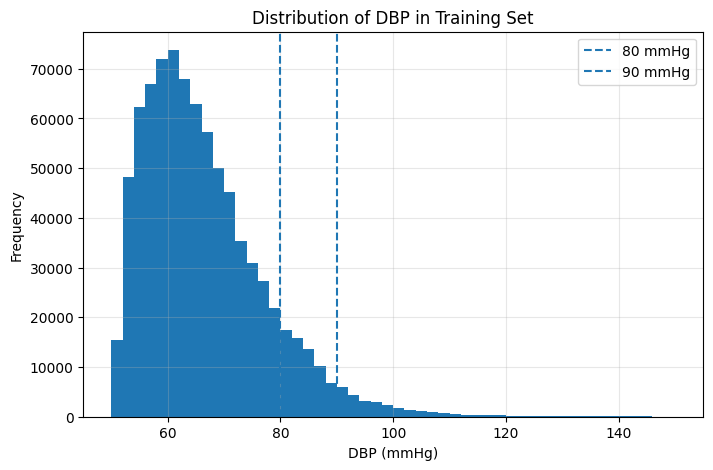

In [15]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("DBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of DBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: DBP
RMSE: 10.6911
MSE : 114.2987
R²  : 0.0870
MAE : 8.4014


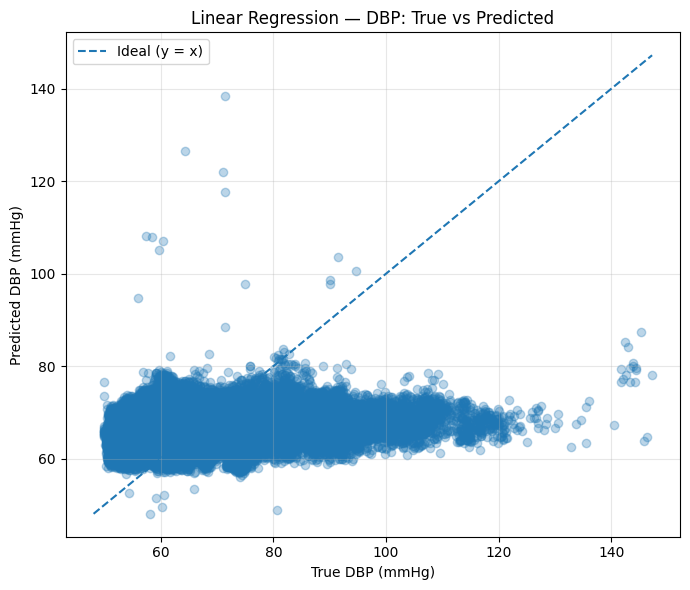

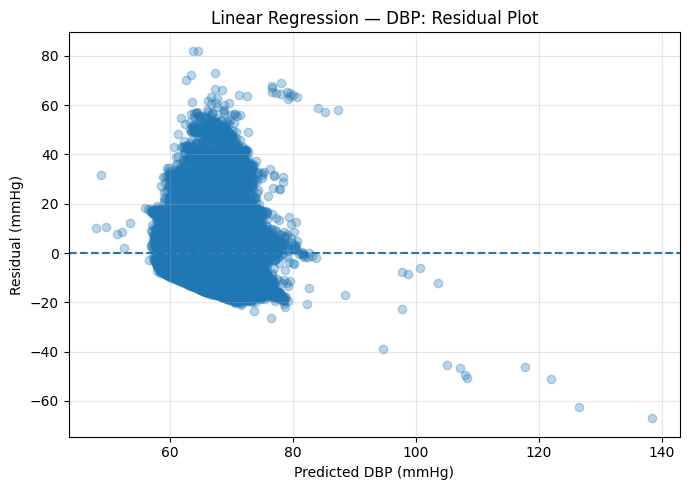

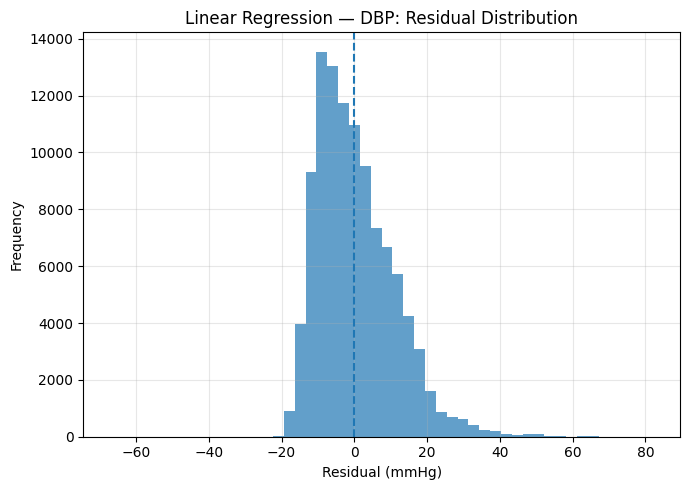

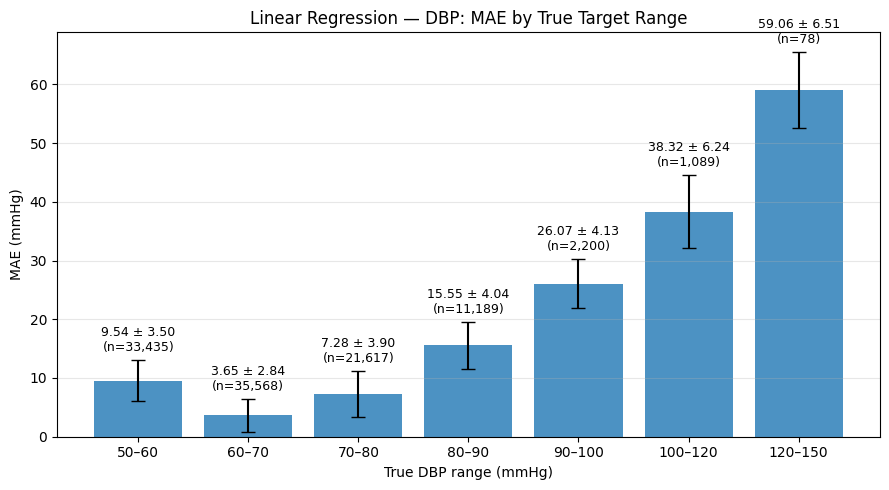

In [16]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 17.9479
MSE : 322.1255
R²  : -0.9834
MAE : 14.1074


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


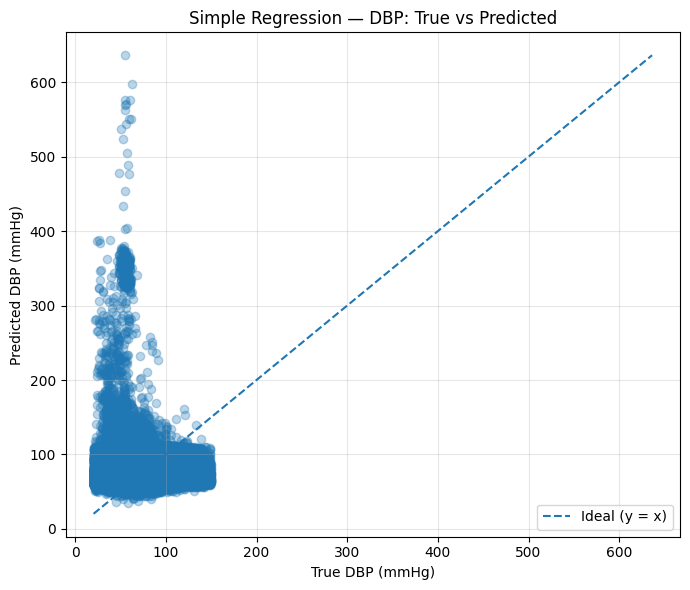

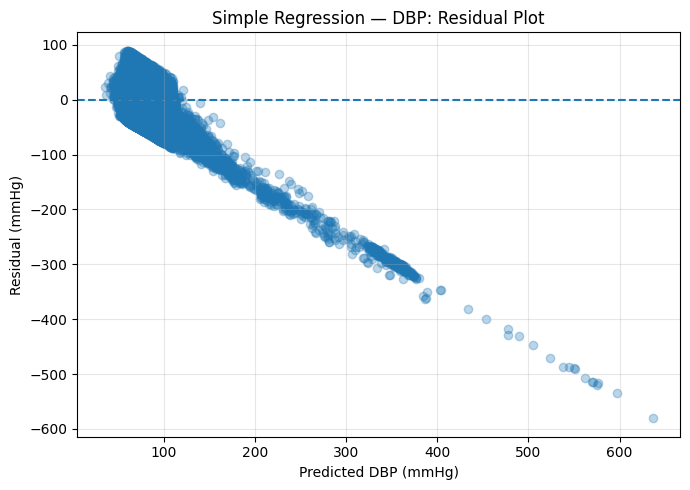

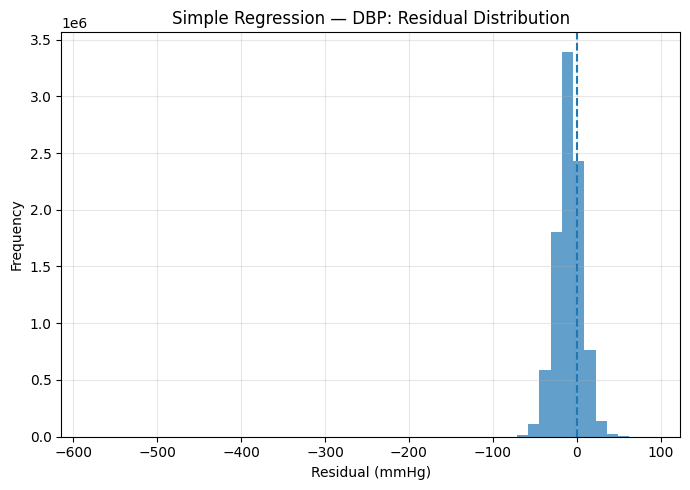

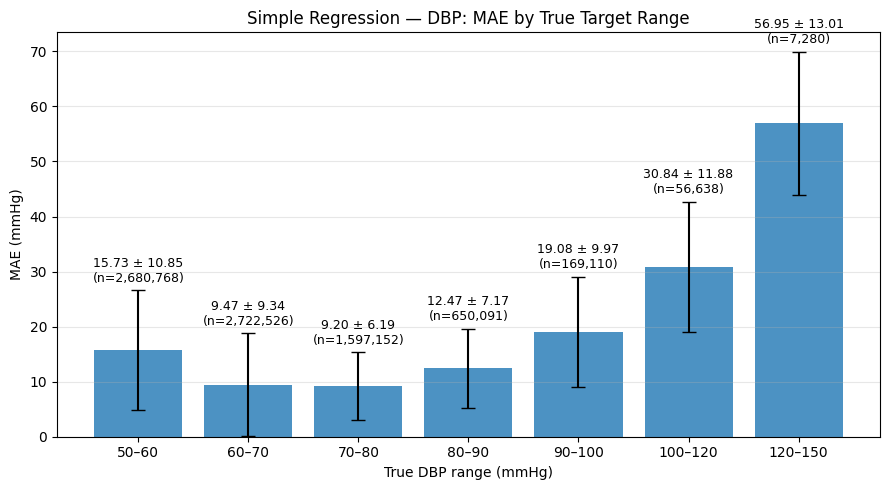

In [17]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — DBP
---------------------------------------------
RMSE: 10.2947
MSE : 105.9803
R²  : 0.1534
MAE : 8.0628


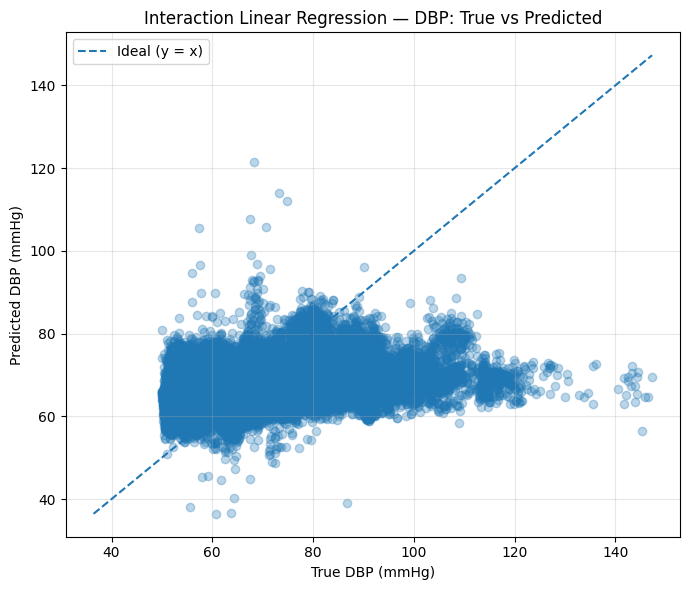

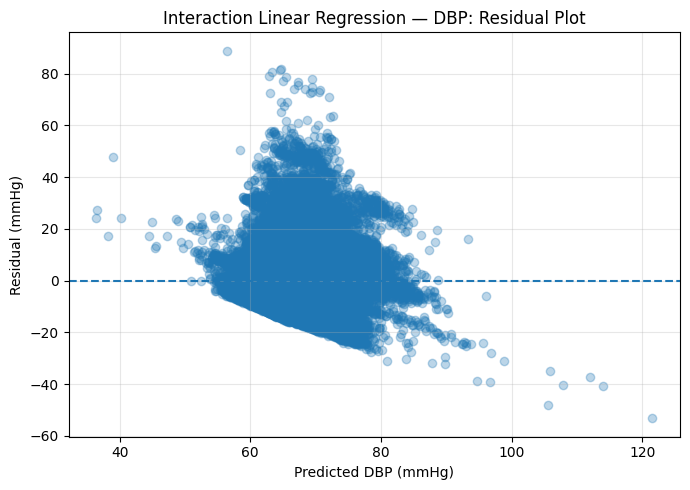

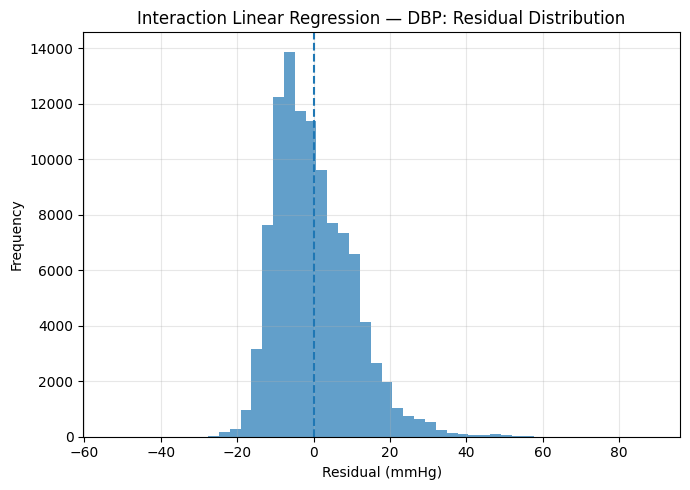

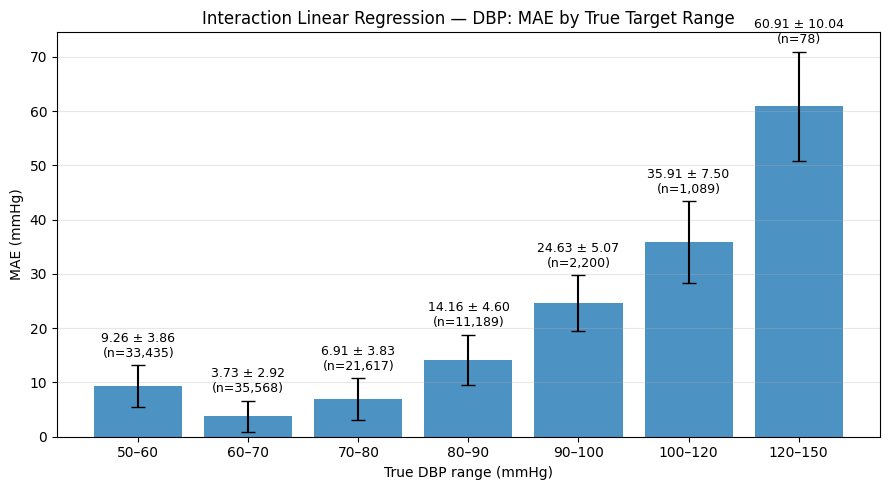

In [18]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 33.6847
MSE : 1134.6566
R²  : -5.9862
MAE : 19.3818


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


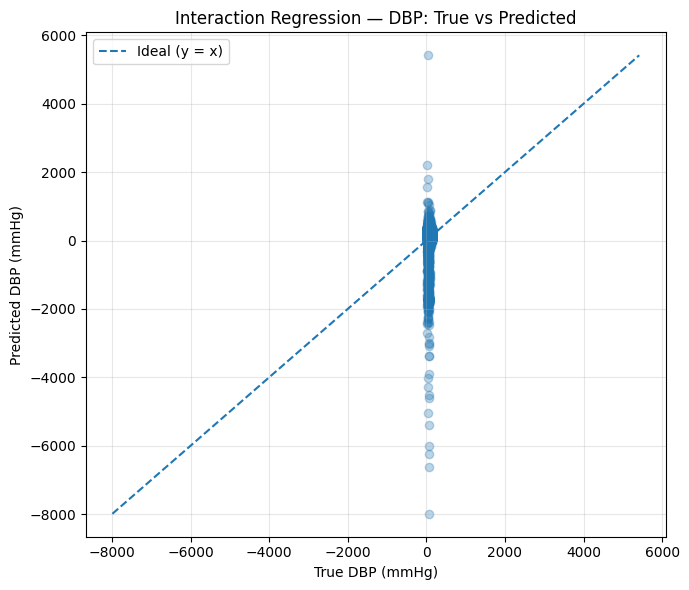

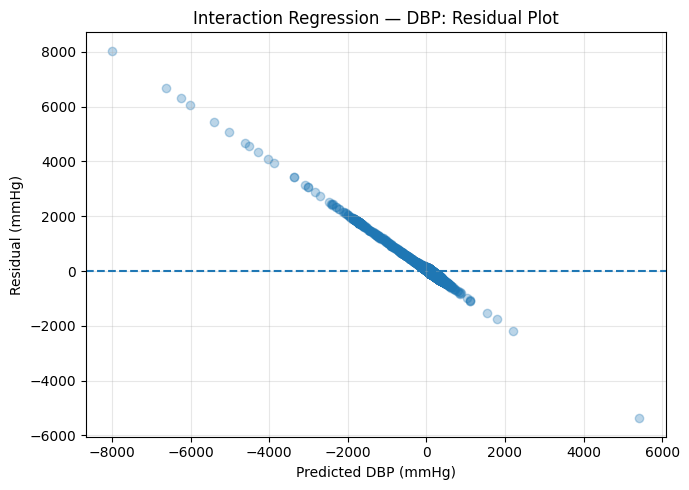

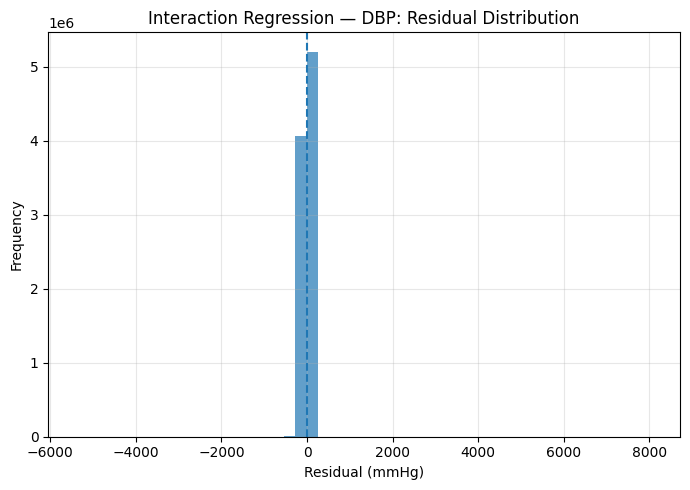

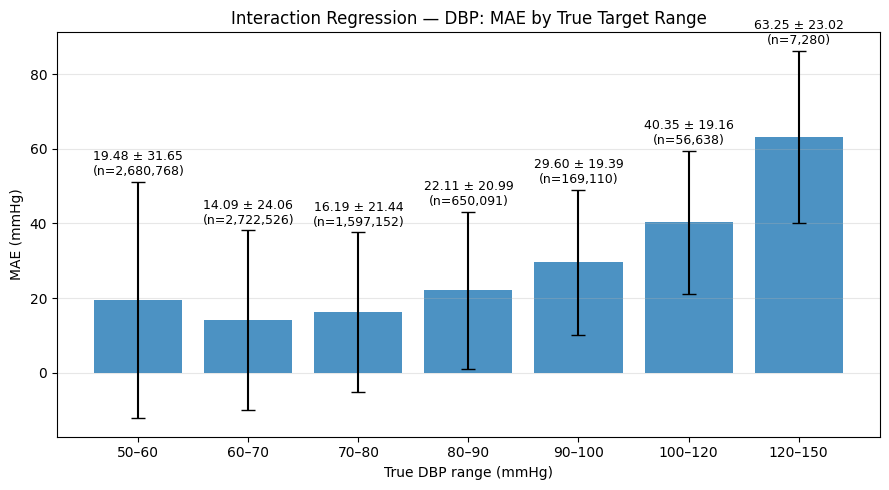

In [19]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — DBP
----------------------------------------
RMSE: 10.7210
MSE : 114.9392
R²  : 0.0818
MAE : 8.3353


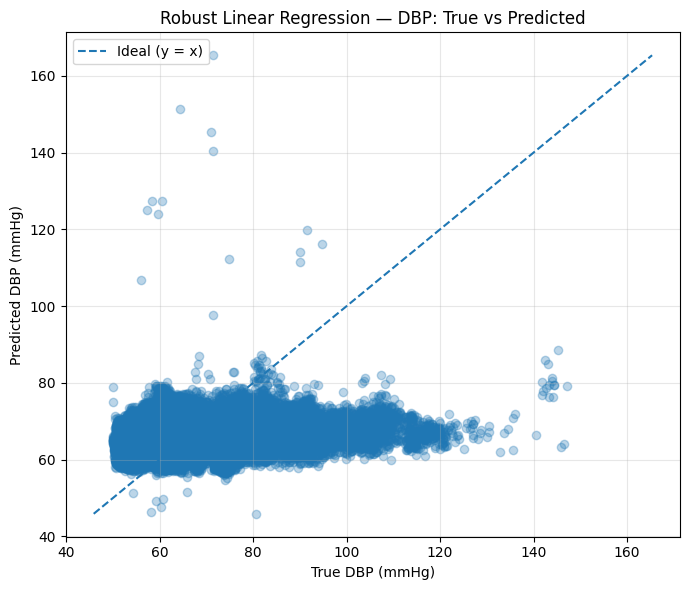

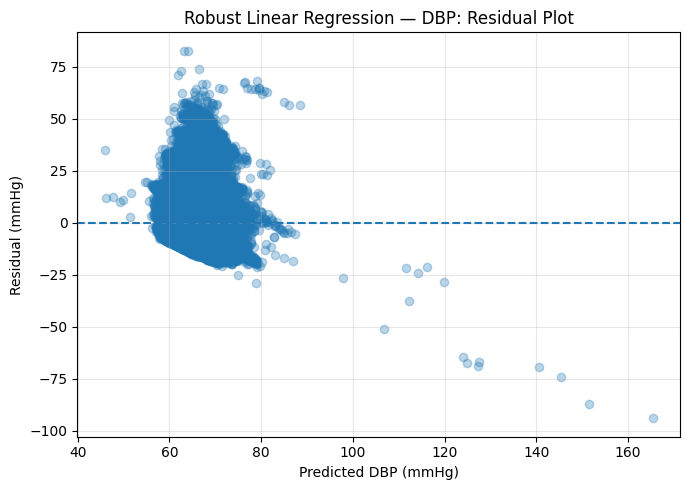

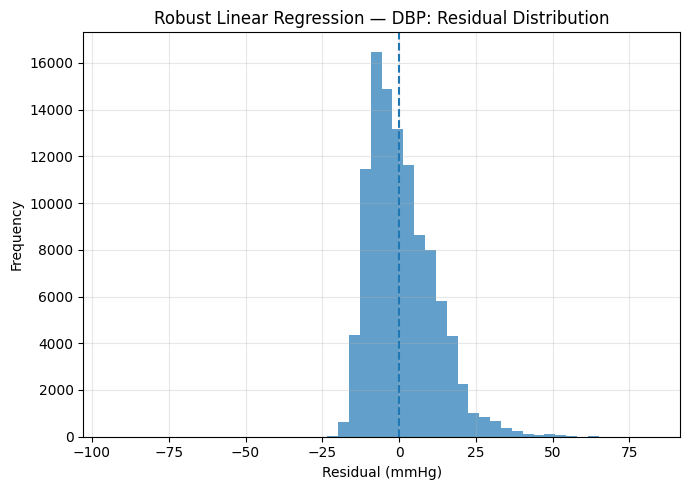

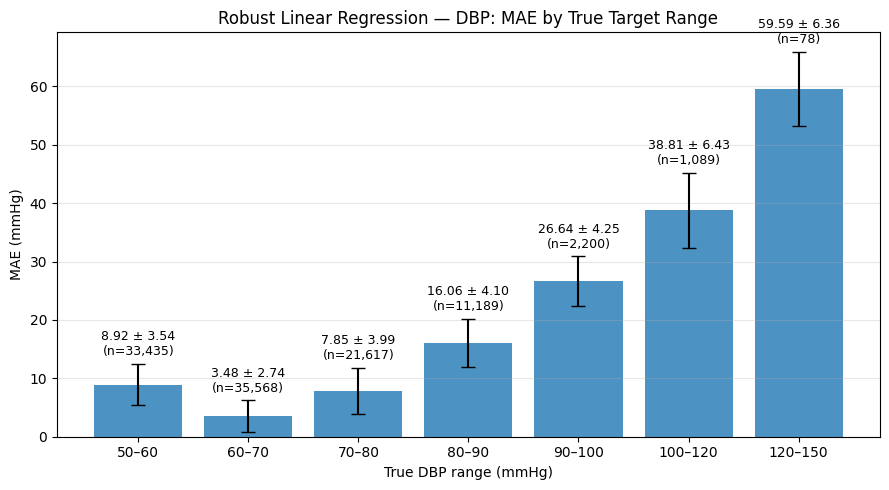

In [20]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 19.3112
MSE : 372.9232
R²  : -1.2961
MAE : 14.9934


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


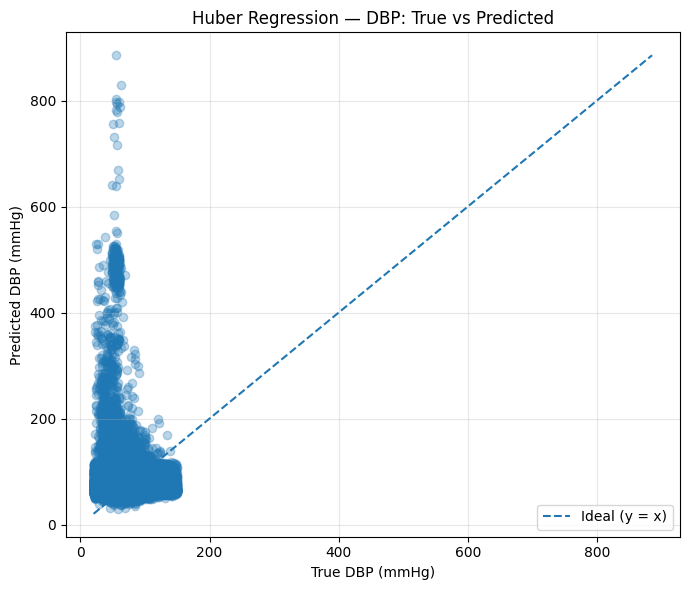

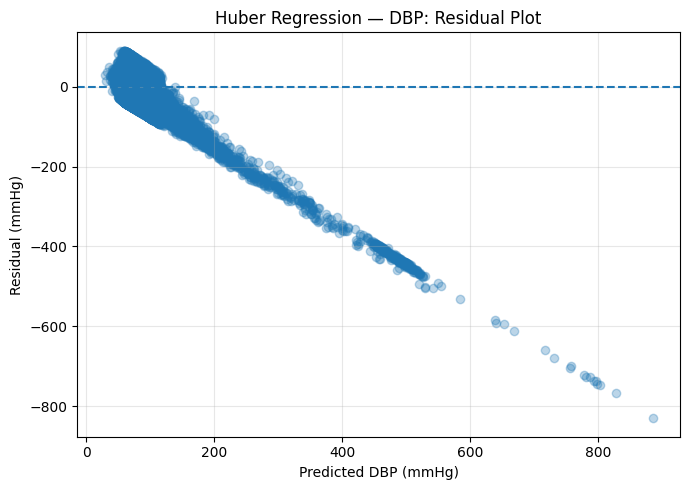

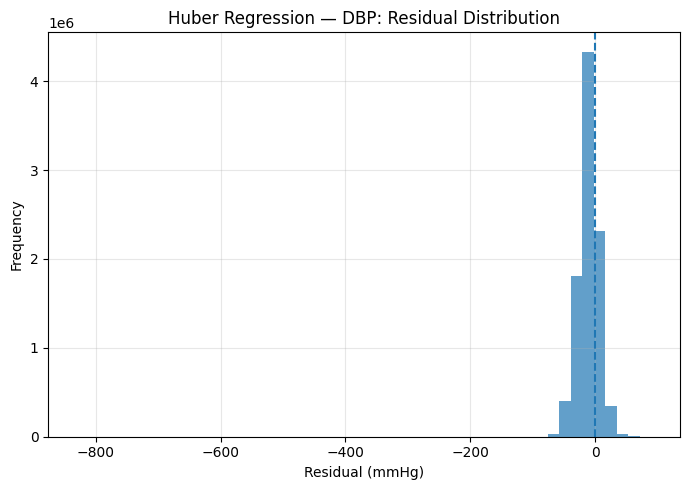

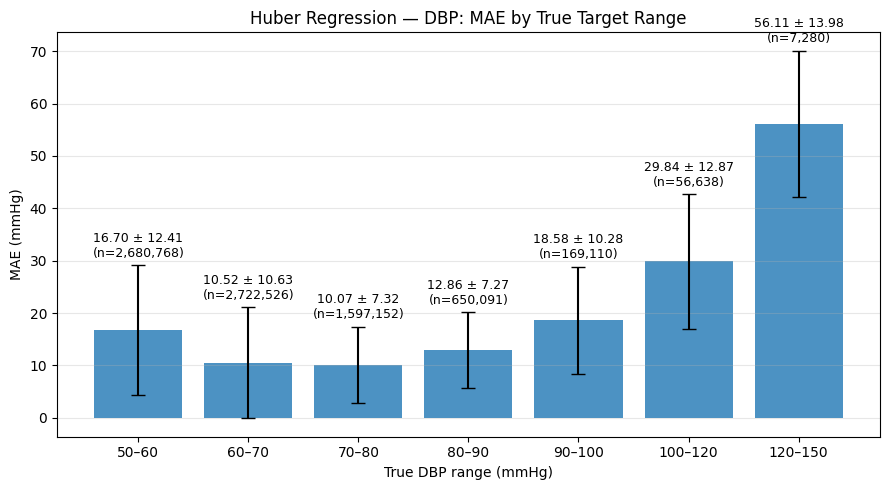

In [21]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — DBP
--------------------------------
RMSE: 10.1586
MSE : 103.1978
R²  : 0.1756
MAE : 7.7100


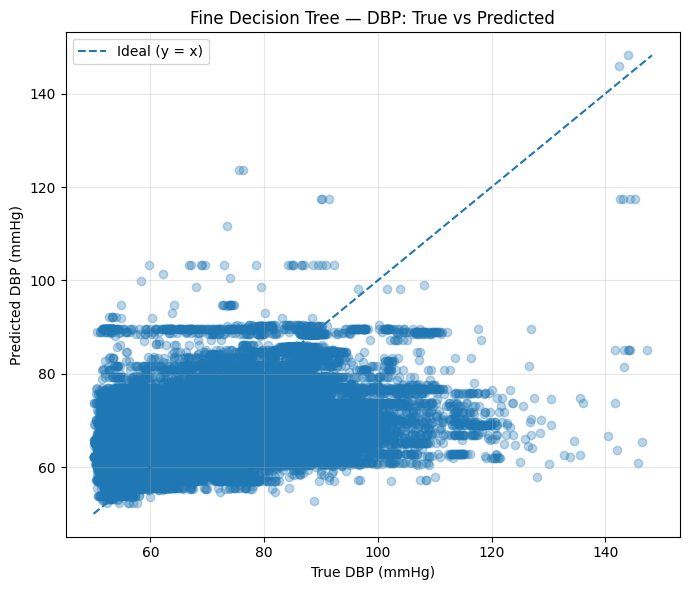

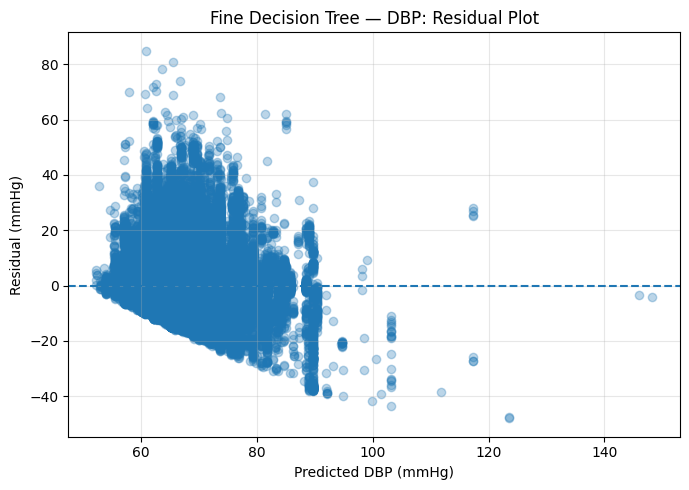

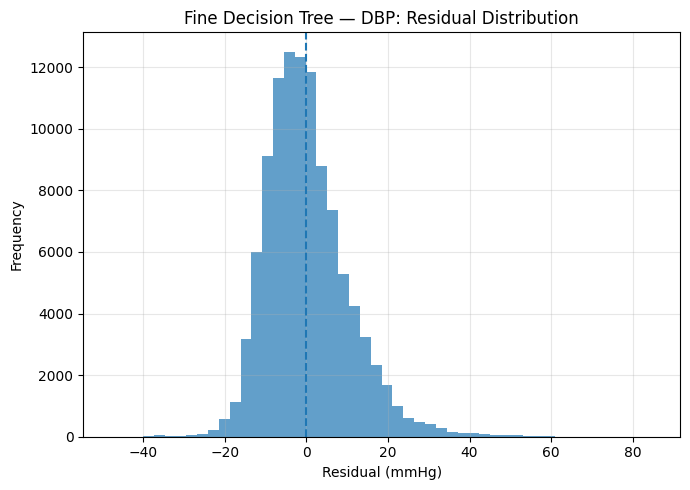

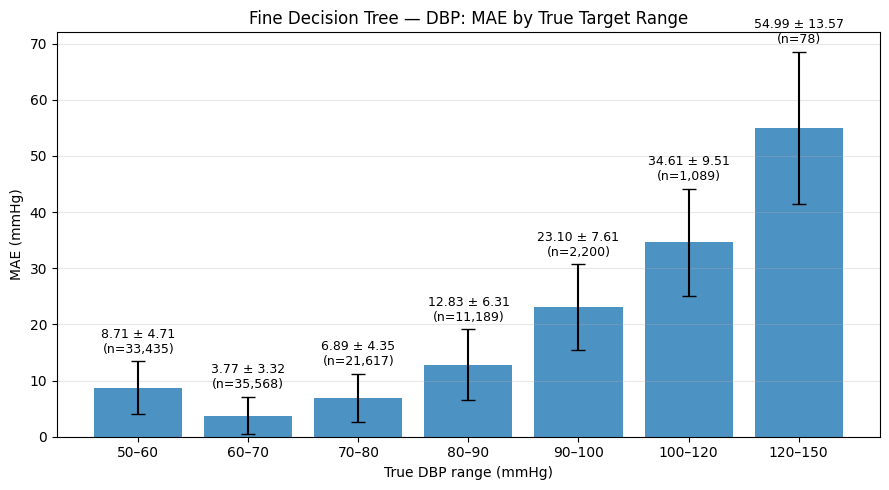

In [22]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 14.4023
MSE : 207.4270
R²  : -0.2772
MAE : 11.3374


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


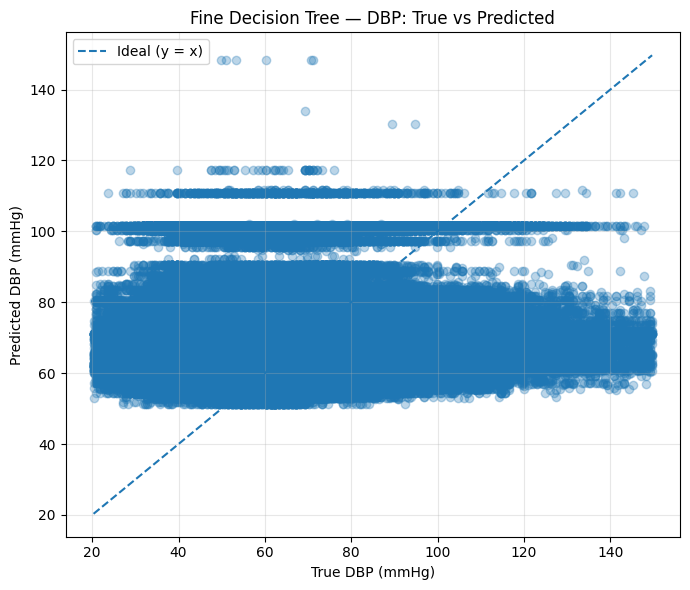

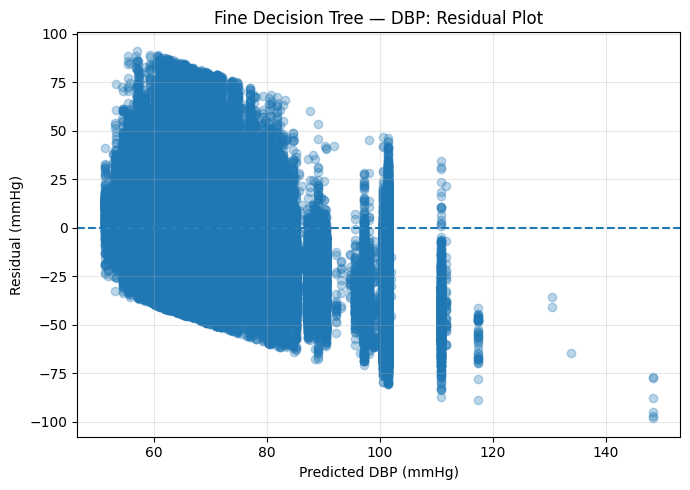

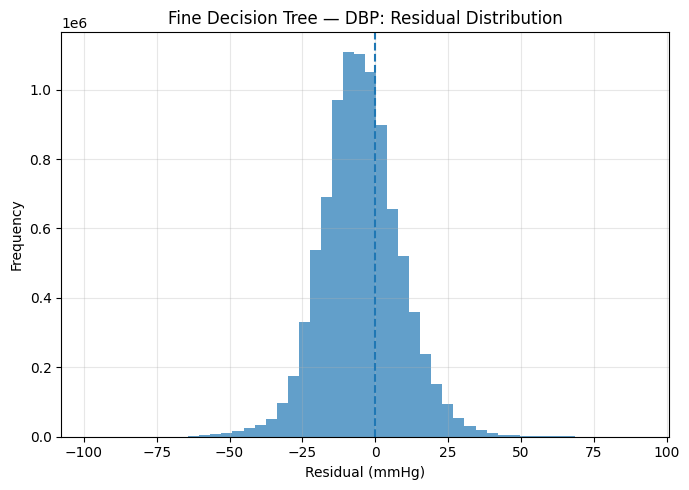

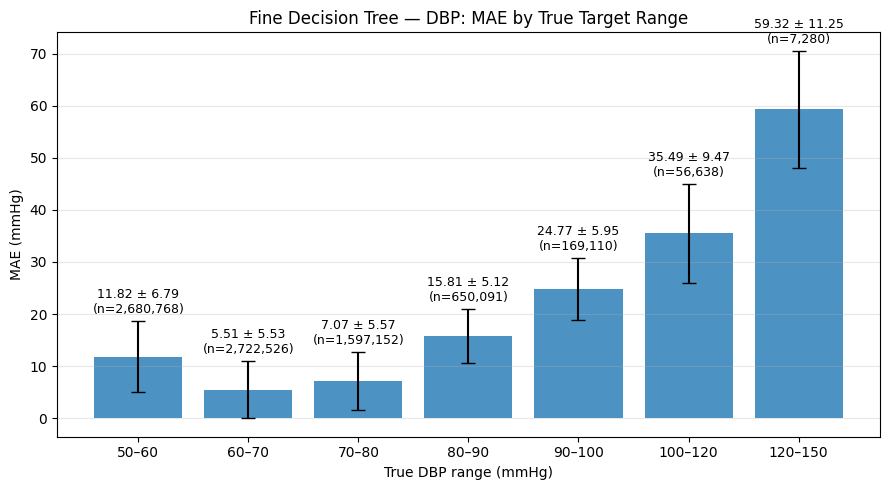

In [23]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — DBP
----------------------------
RMSE: 8.9171
MSE : 79.5153
R²  : 0.3648
MAE : 6.5109


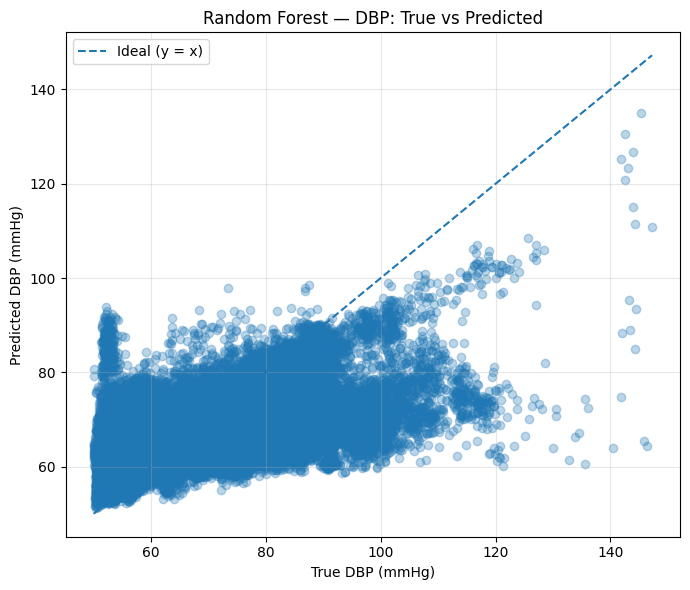

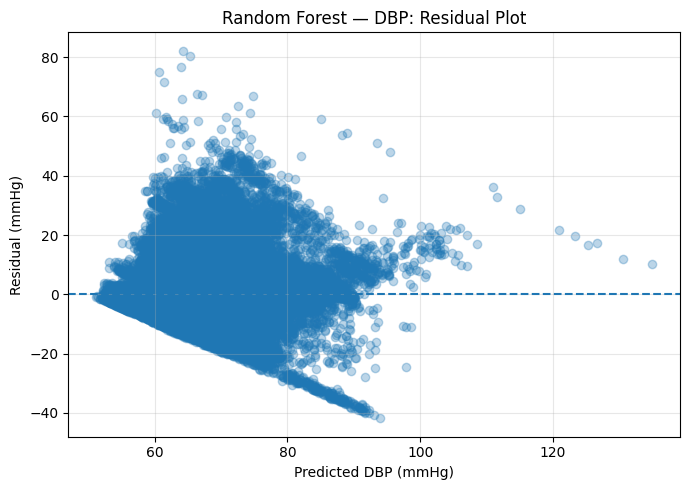

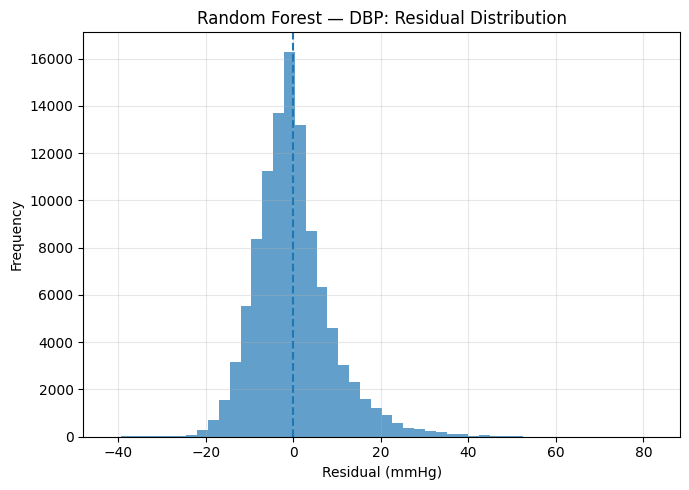

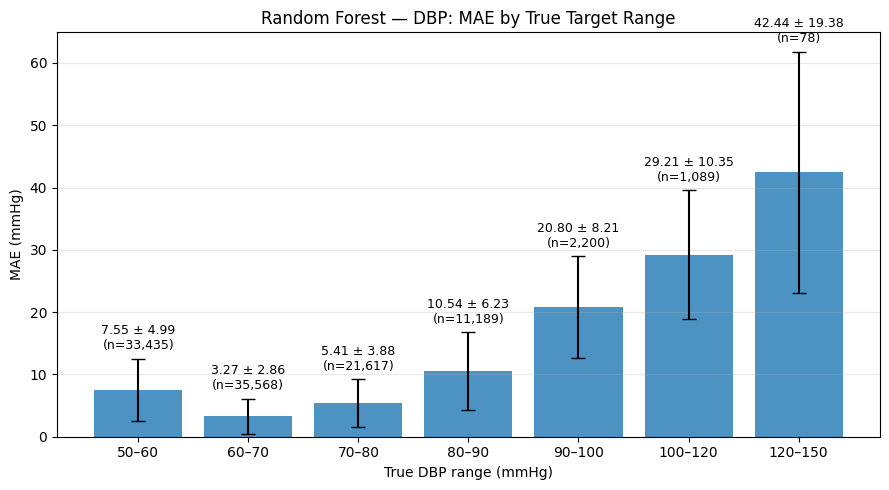

In [24]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 14.7688
MSE : 218.1175
R²  : -0.3430
MAE : 11.9642


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


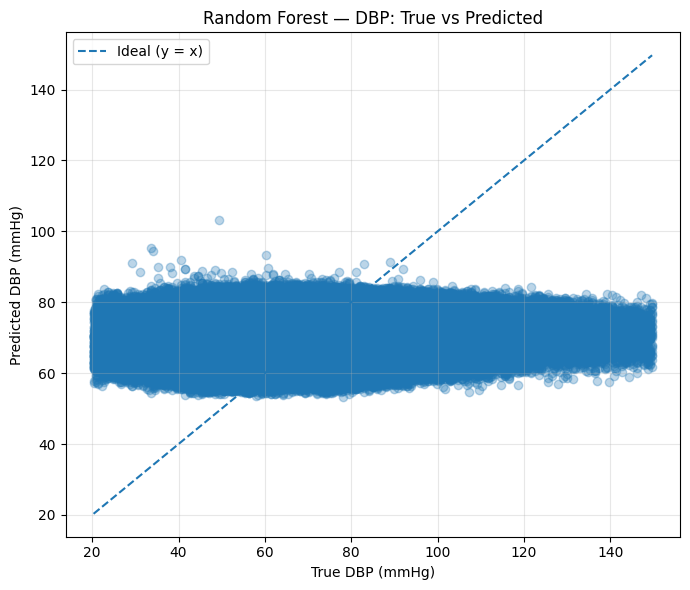

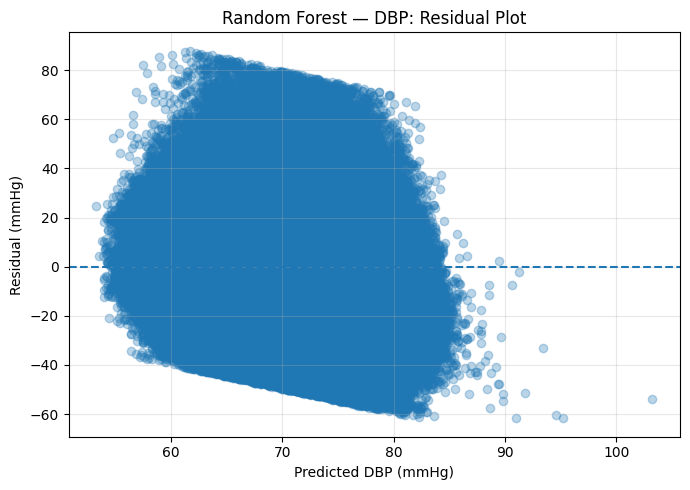

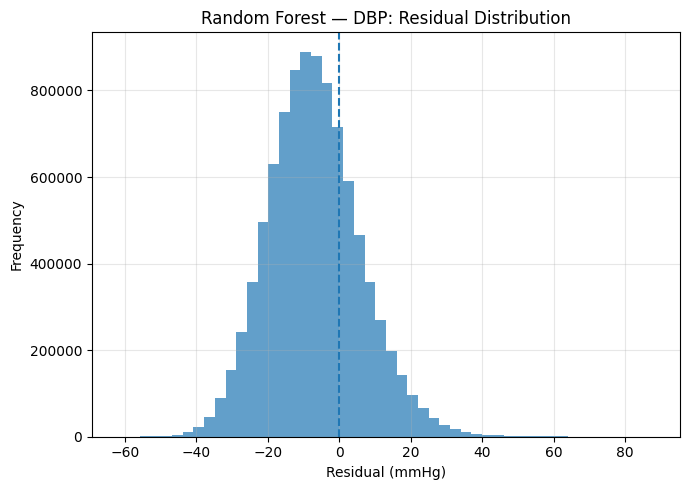

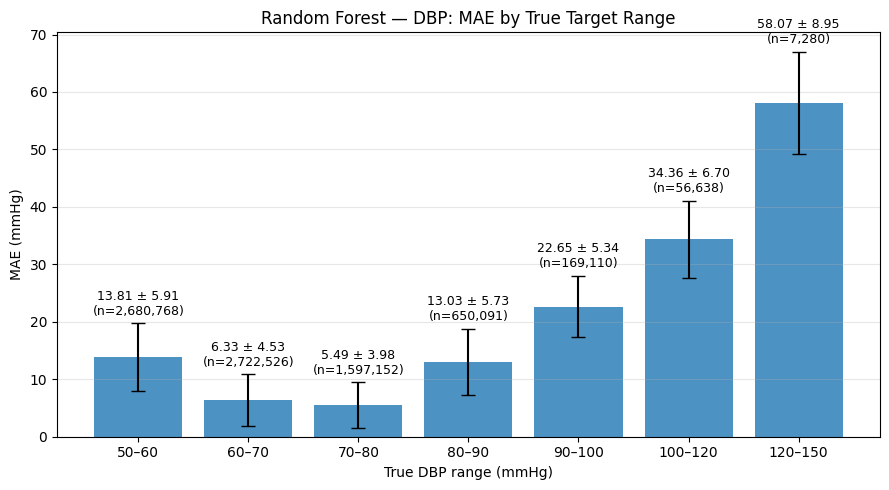

In [25]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — DBP
--------------------------------------
RMSE: 8.9119
MSE : 79.4217
R²  : 0.3656
MAE : 6.4549


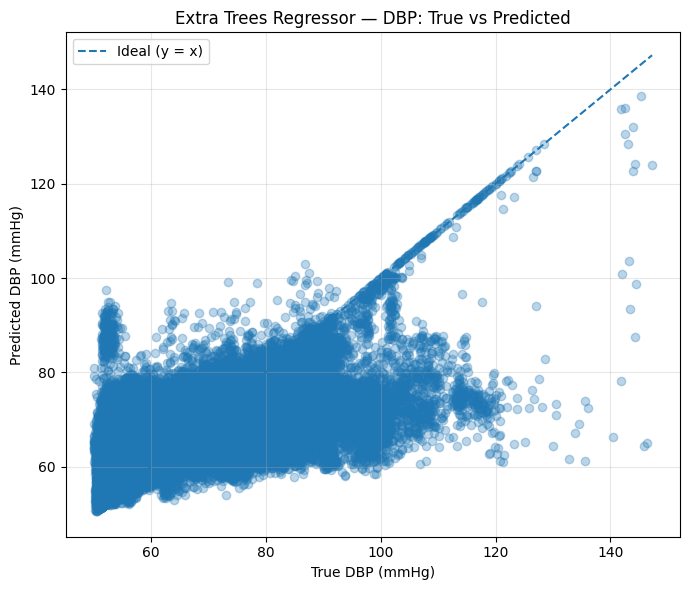

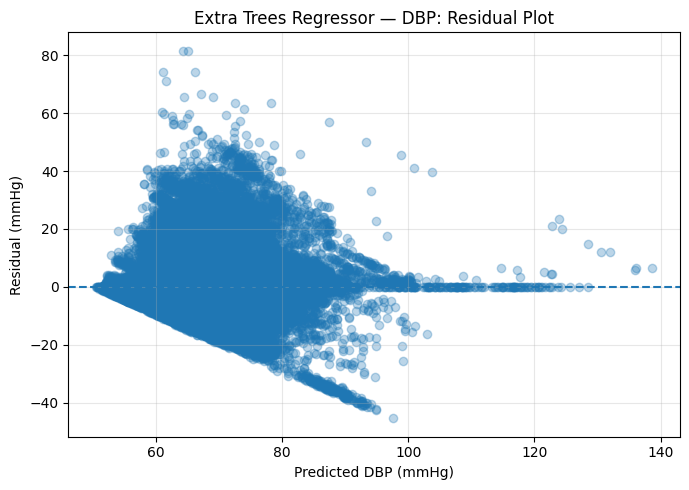

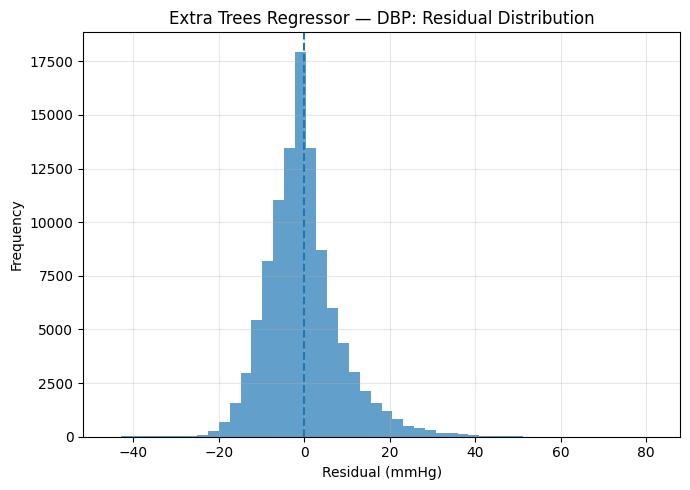

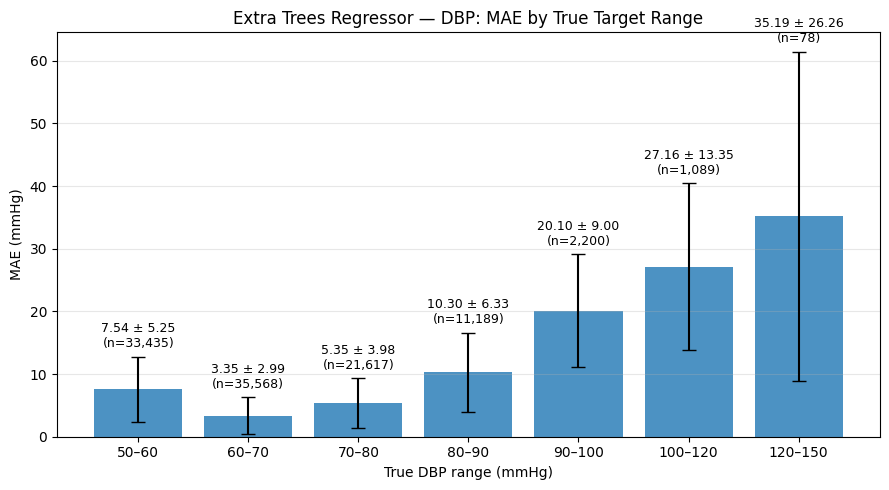

In [26]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 15.7680
MSE : 248.6297
R²  : -0.5308
MAE : 12.8326


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


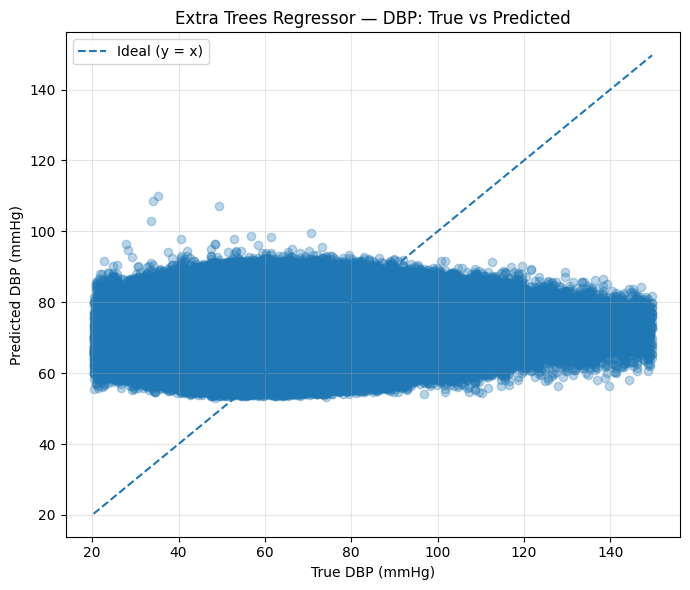

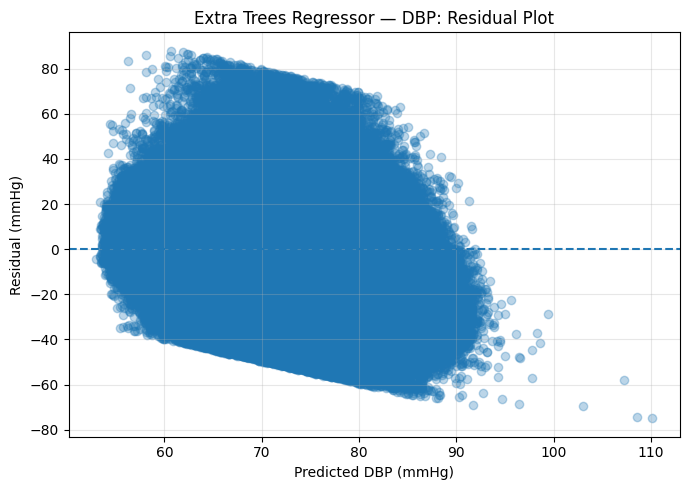

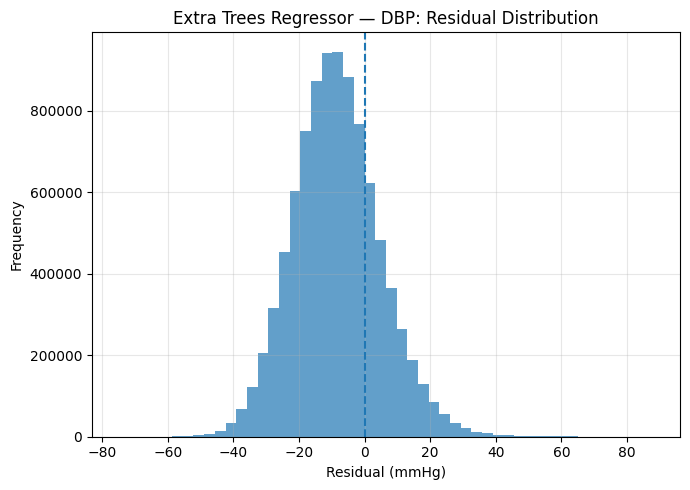

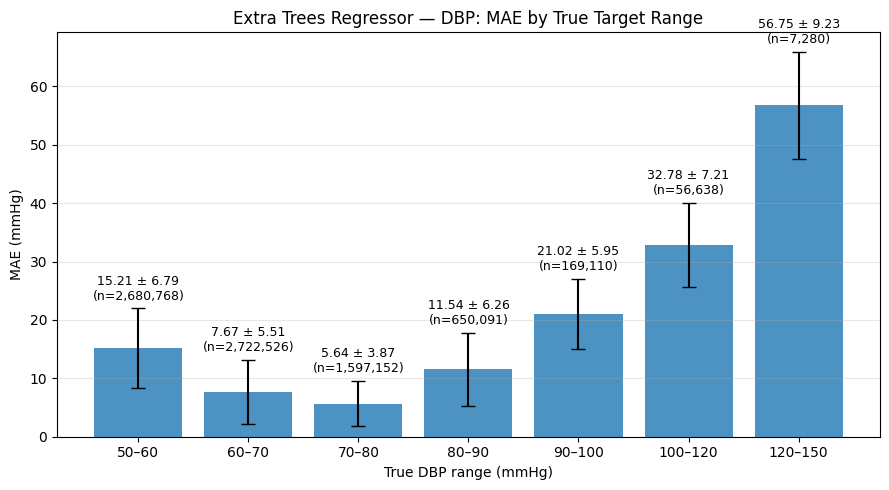

In [27]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — DBP
---------------------
RMSE: 9.4964
MSE : 90.1825
R²  : 0.2796
MAE : 7.0717


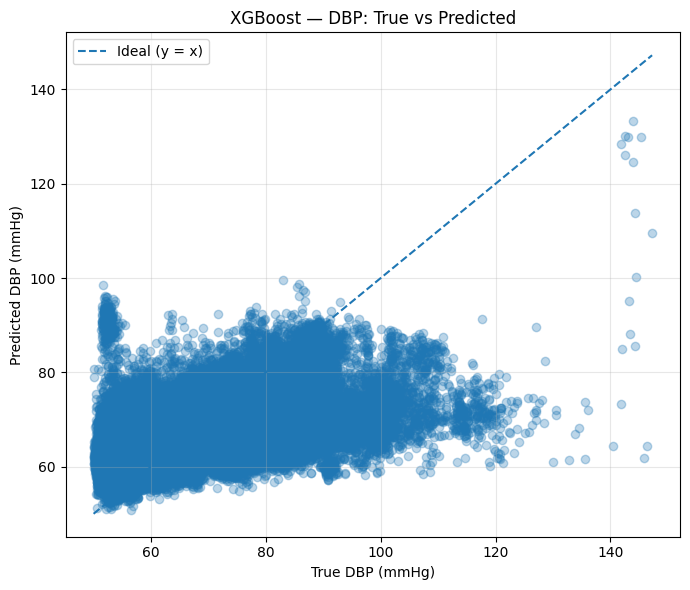

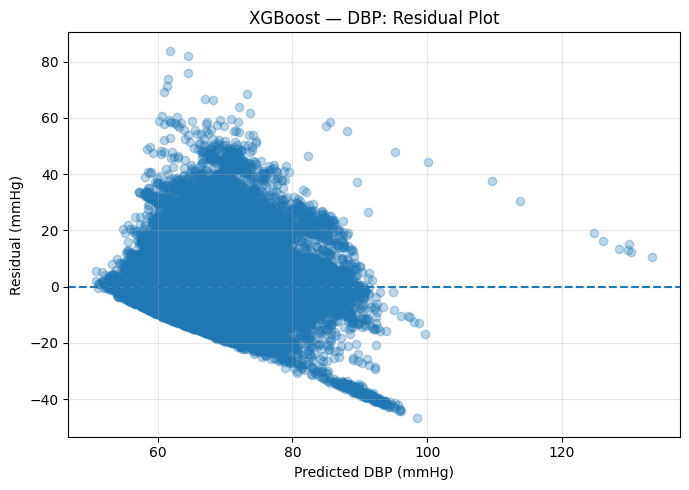

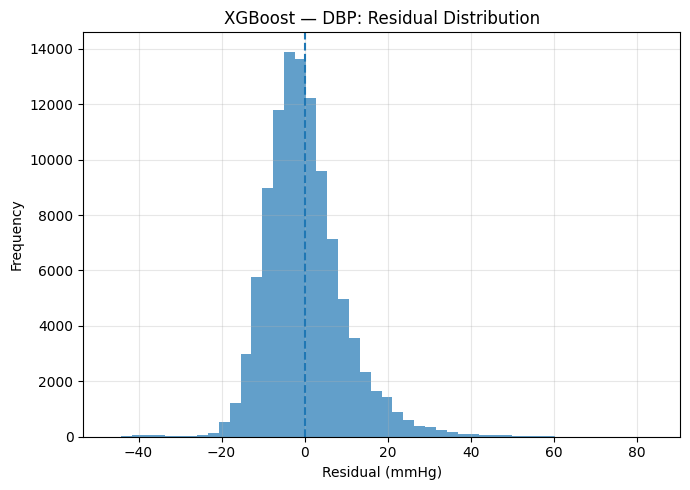

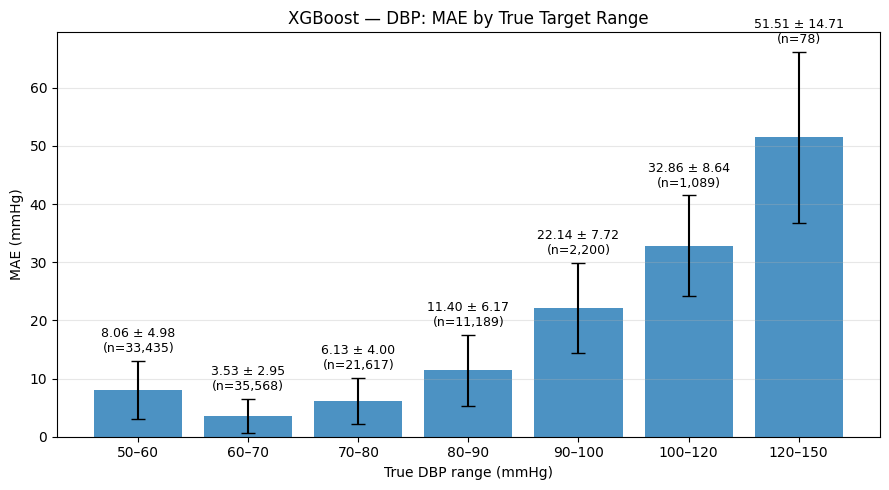

In [28]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 14.1467
MSE : 200.1290
R²  : -0.2322
MAE : 11.3452


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


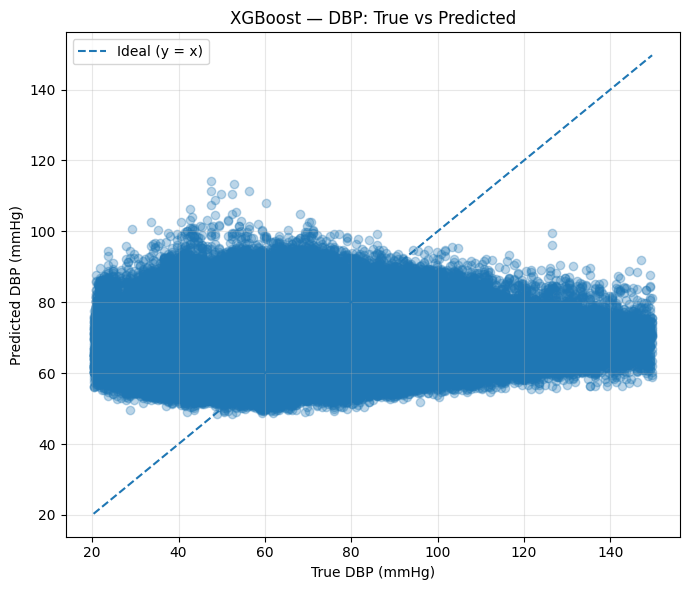

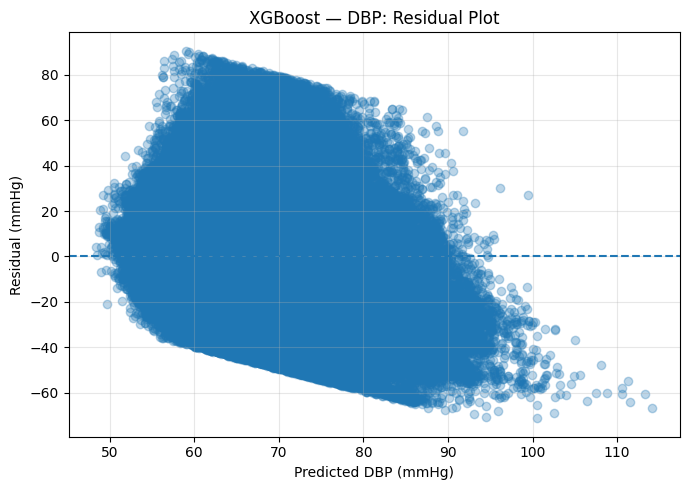

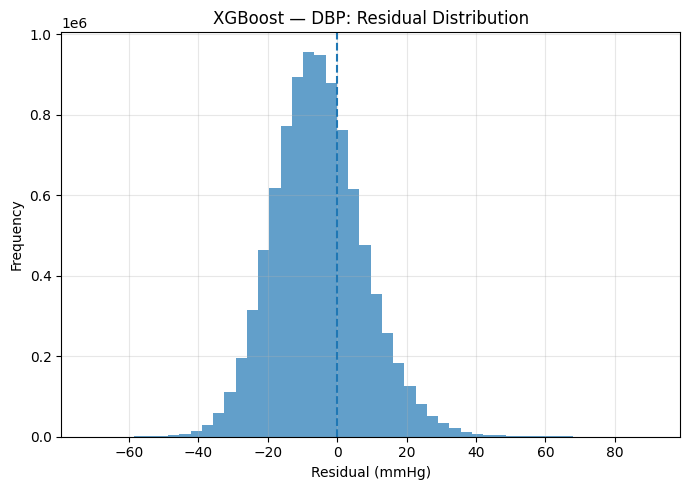

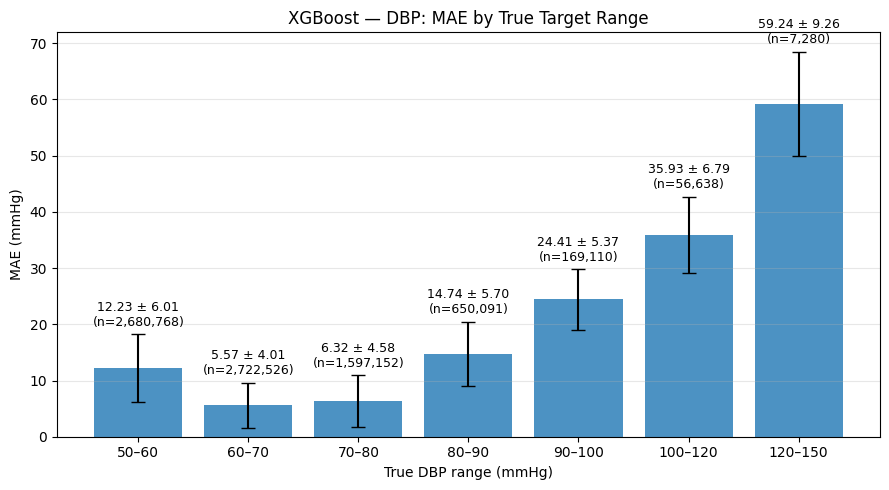

In [29]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 1.7min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 5.2min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 5.6min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time= 4.1min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time= 9.6min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=10.2min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=10.3min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=10.5min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 4.9min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total ti

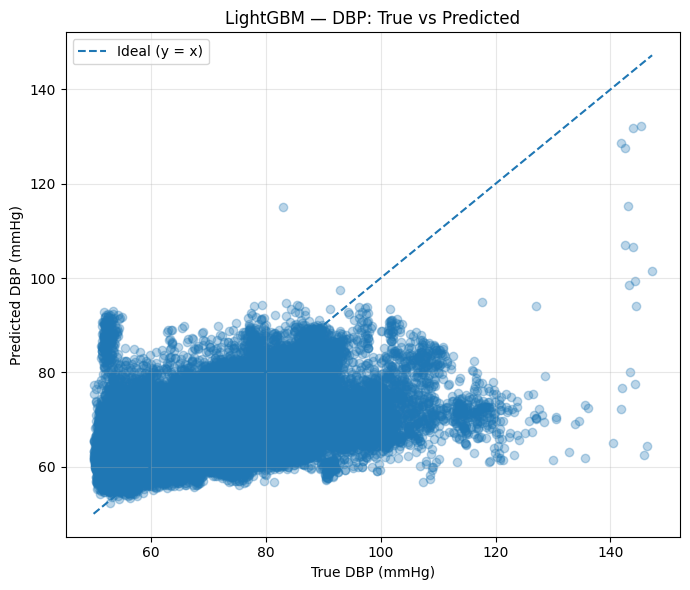

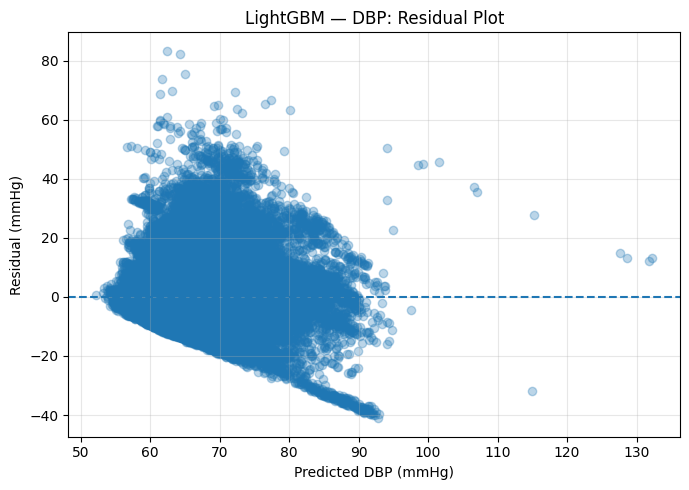

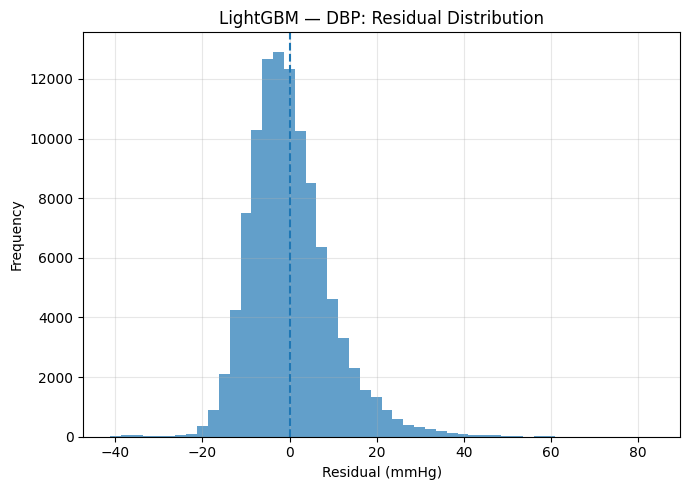

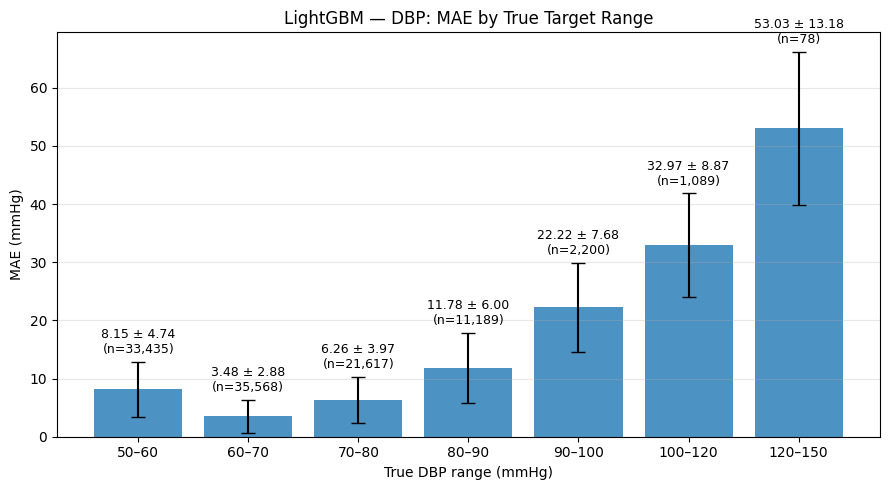

In [30]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.1038
MSE : 171.7106
R²  : -0.0572
MAE : 10.4366


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


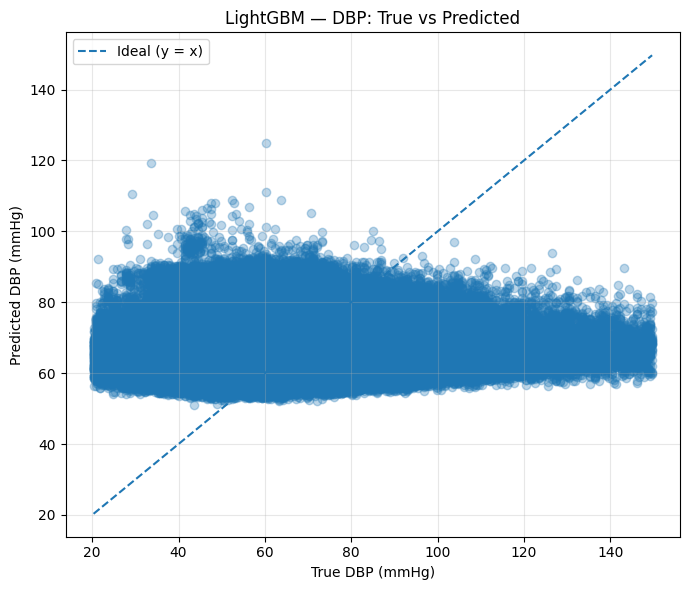

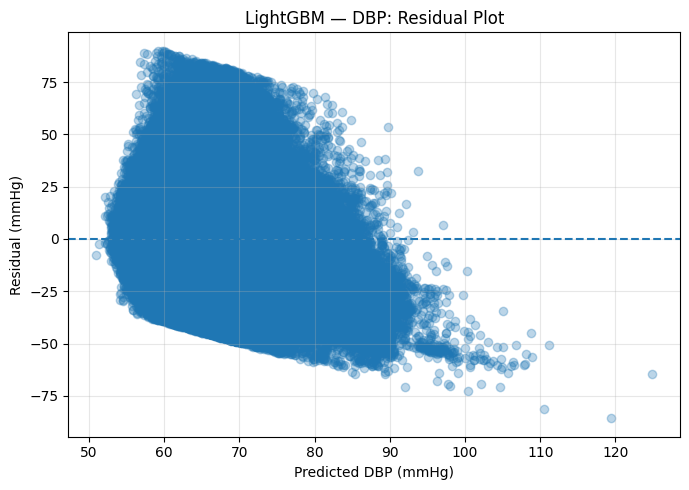

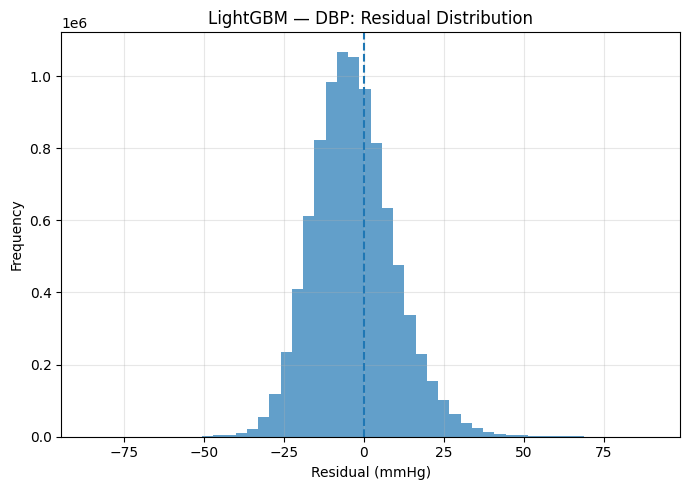

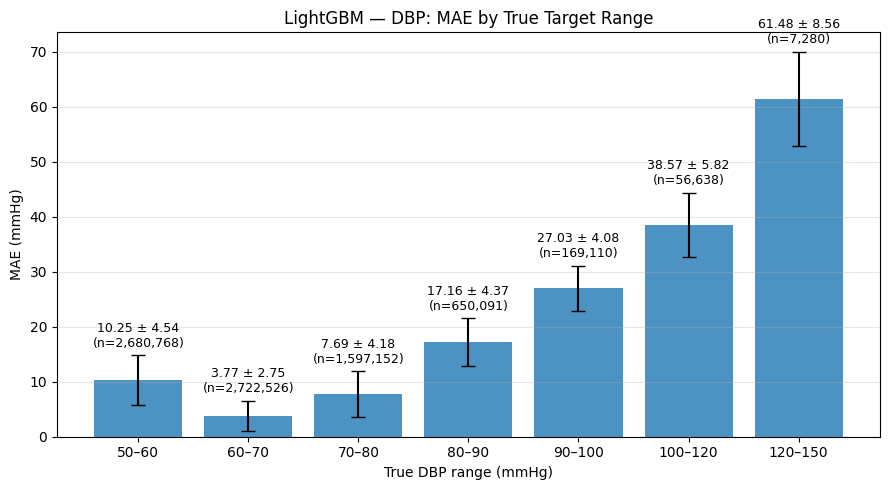

In [31]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Best parameters:
{'kernel': 1**2 * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — DBP
--------------------------------
RMSE: 10.1713
MSE : 103.4551
R²  : 0.1736
MAE : 7.8165


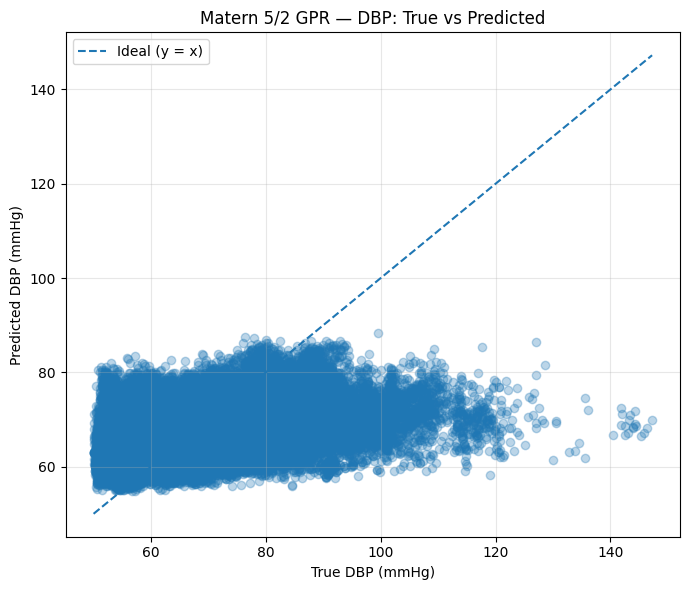

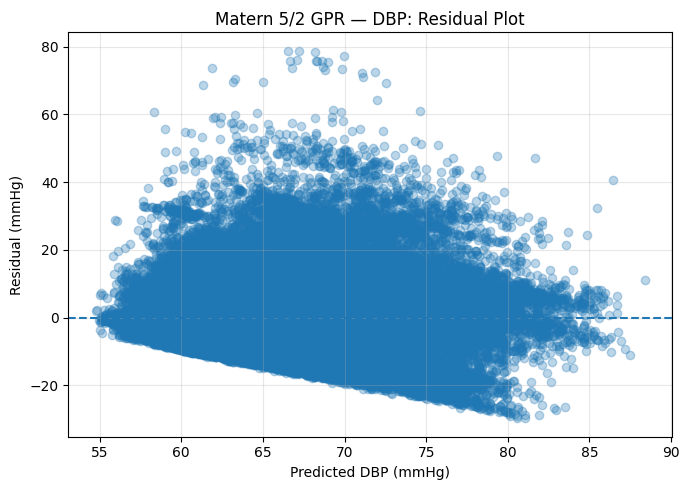

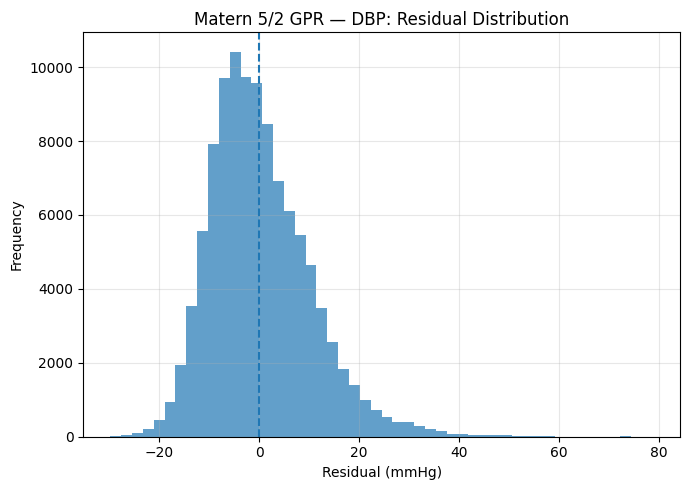

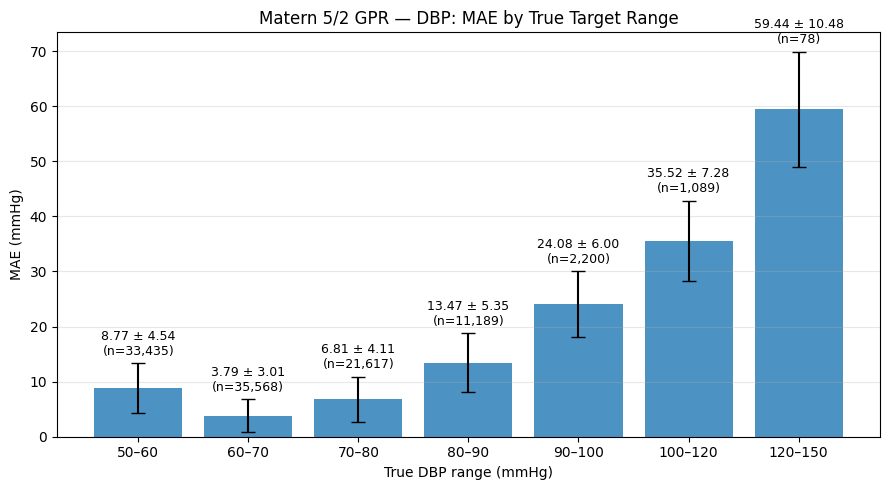

In [32]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 13.0963
MSE : 171.5135
R²  : -0.0560
MAE : 10.4766


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


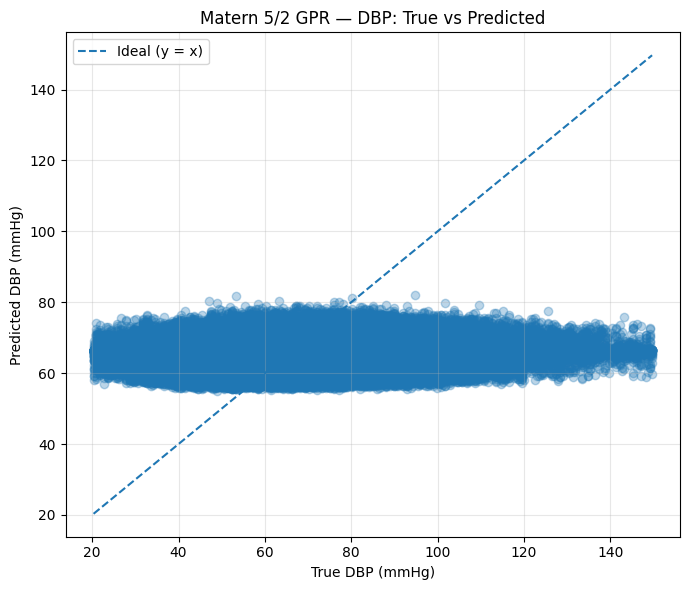

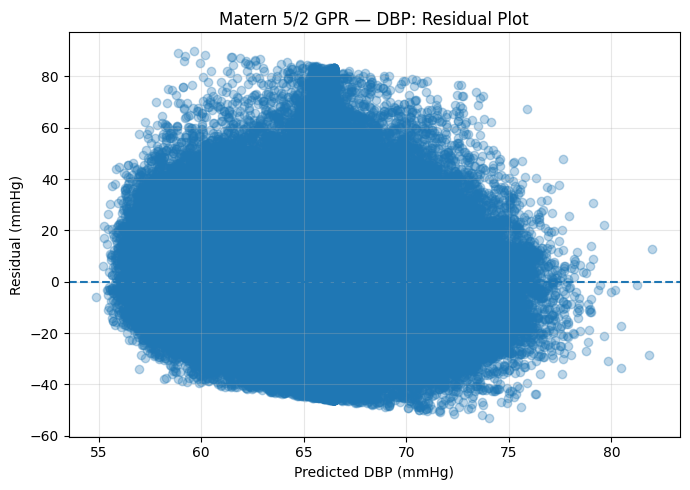

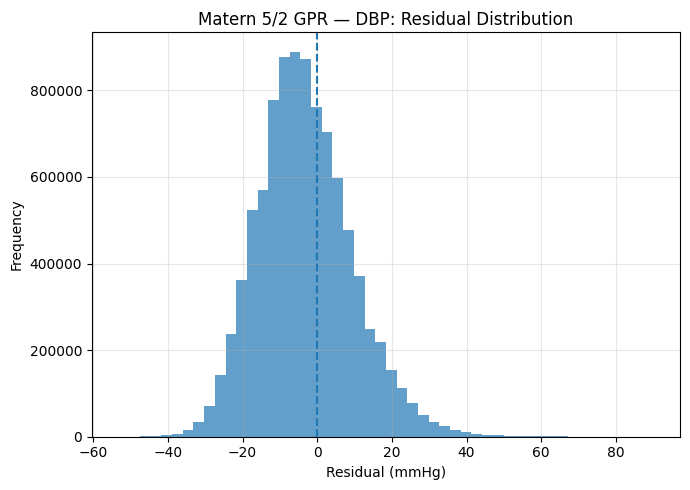

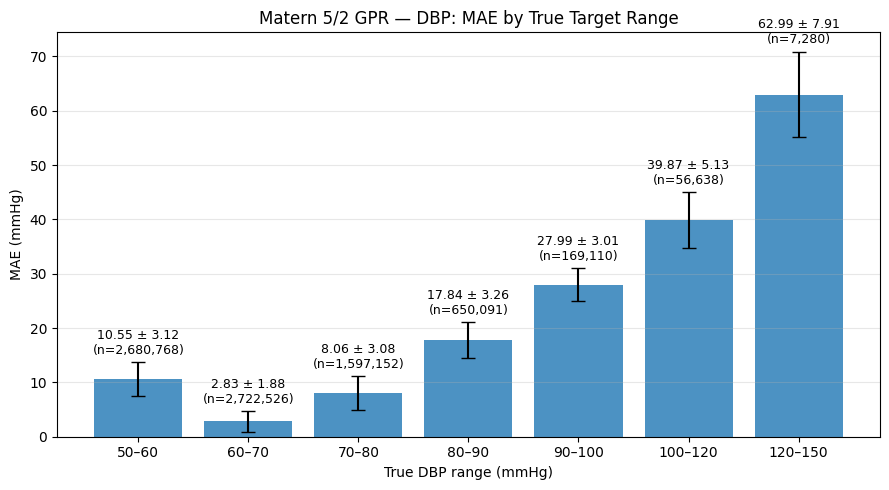

In [33]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 9.752880935417743

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 105,176 samples...
RMSE: 10.1545
MSE : 103.1149
R²  : 0.1763
MAE : 7.8017


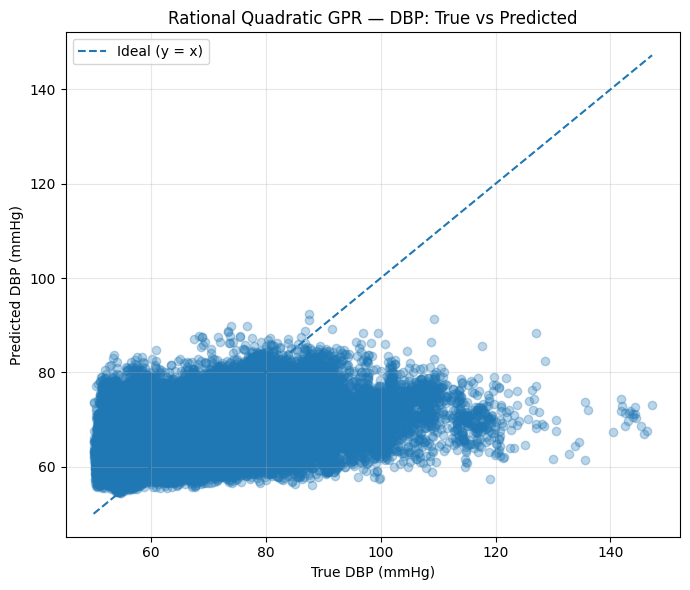

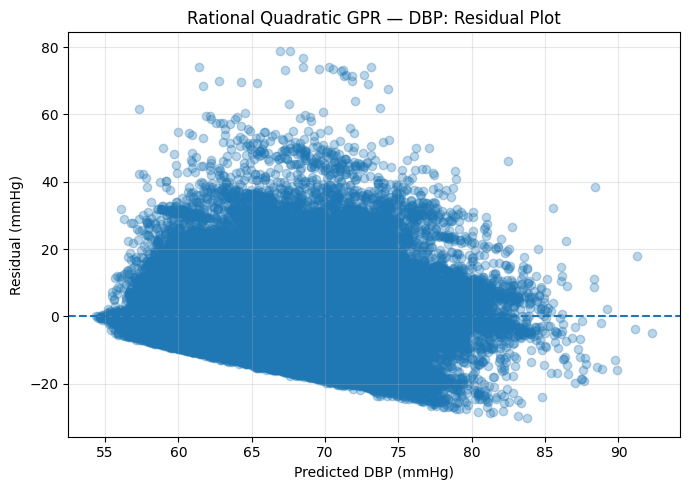

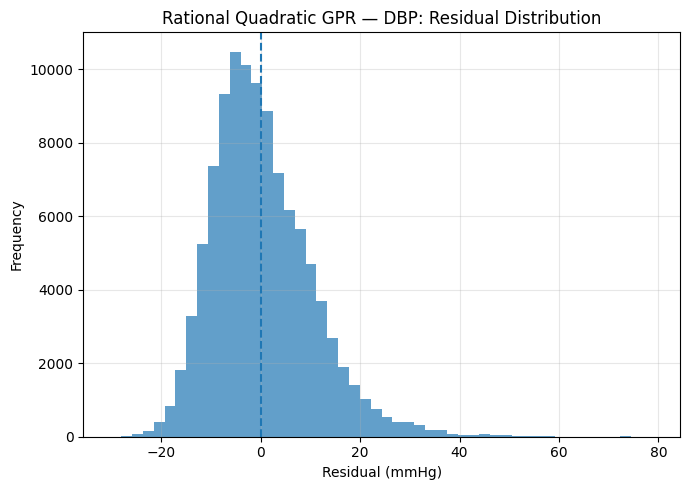

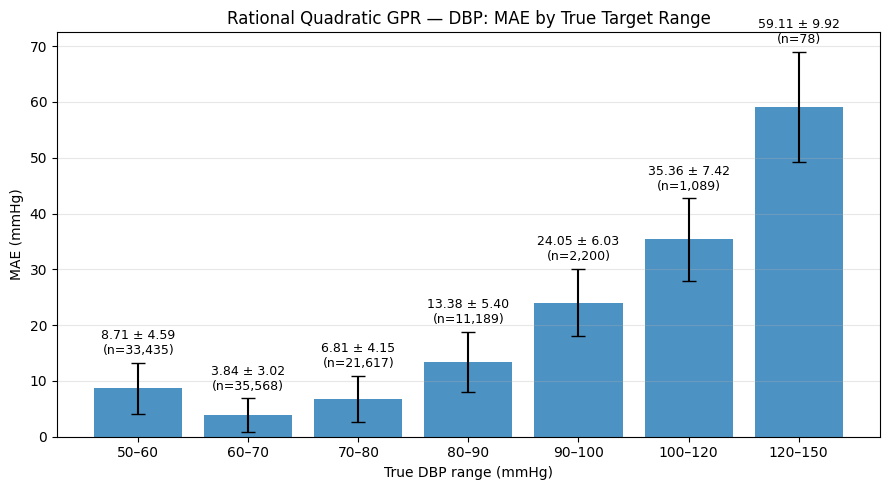

In [34]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 12.8305
MSE : 164.6214
R²  : -0.0136
MAE : 10.1922


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


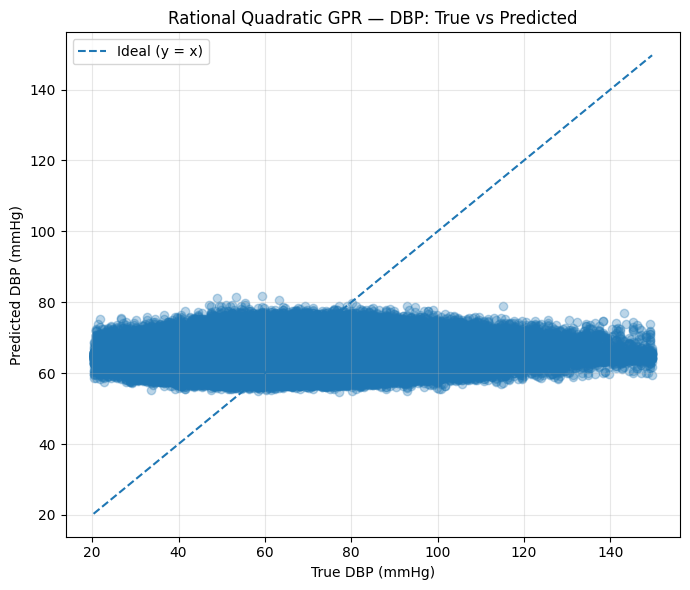

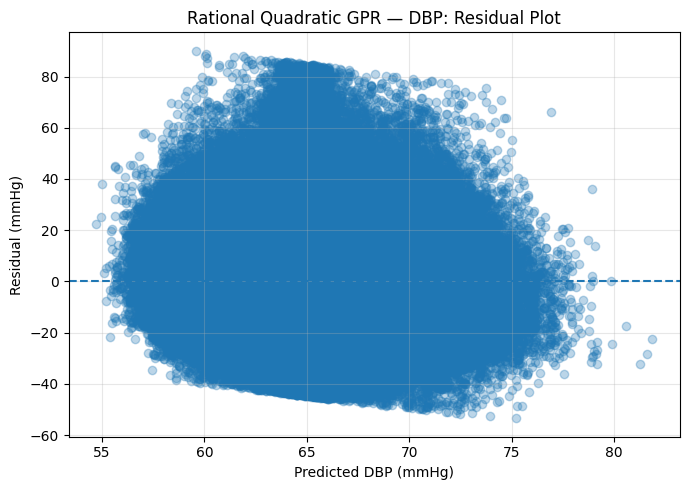

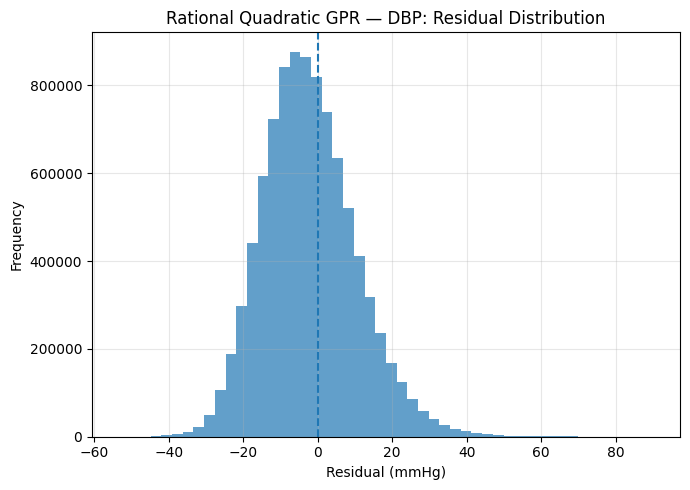

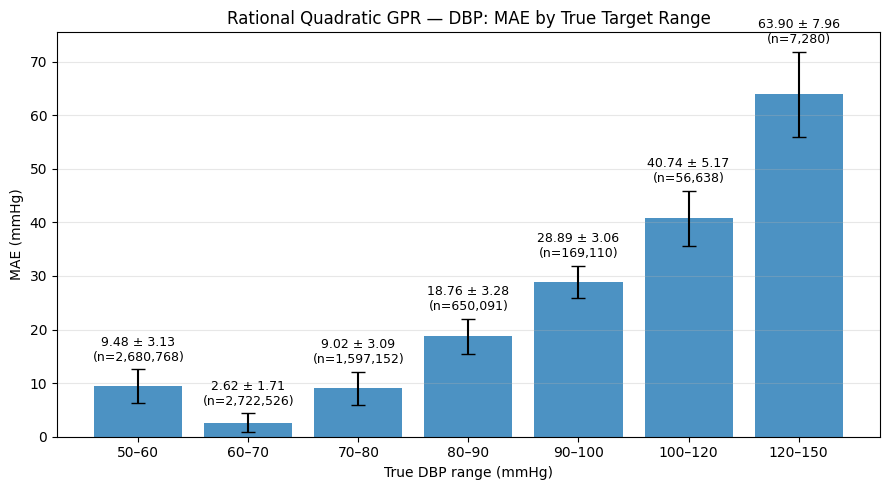

In [35]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 512, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}

Best CV RMSE: 10.059741997362293

Best ANN / MLP model:
MLPRegressor(batch_size=512, early_stopping=True, hidden_layer_sizes=(128, 64),
             learning_rate_init=0.01, max_iter=300, n_iter_no_change=20,
             random_state=42)

Starting batched prediction on 105,176 samples...
Processed 10,000 / 105,176
Processed 20,000 / 105,176
Processed 30,000 / 105,176
Processed 40,000 / 105,176
Processed 50,000 / 105,176
Processed 60,000 / 105,176
Processed 70,000 / 105,176
Processed 80,000 / 105,176
Processed 90,000 / 105,176
Processed 100,000 / 105,176
Processed 105,176 / 105,176

ANN / MLP Regressor — DBP
------------------------------------
RMSE: 10.4615
MSE : 109.4426
R²  : 0.1258
MAE : 7.9787


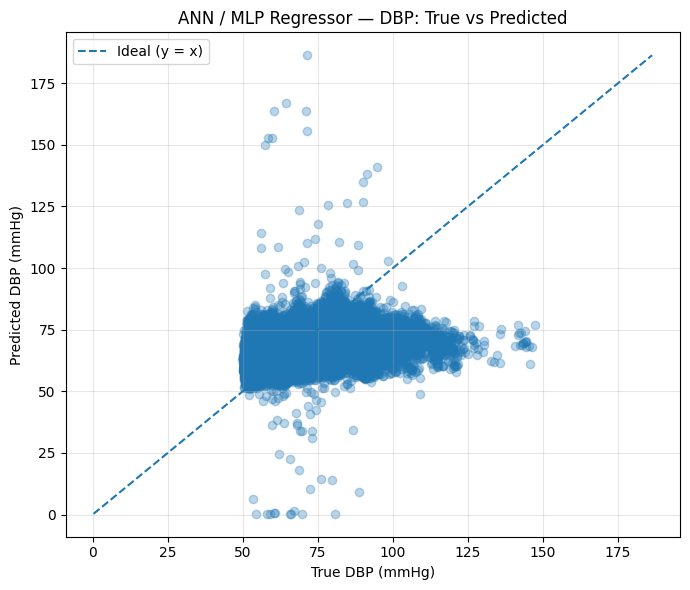

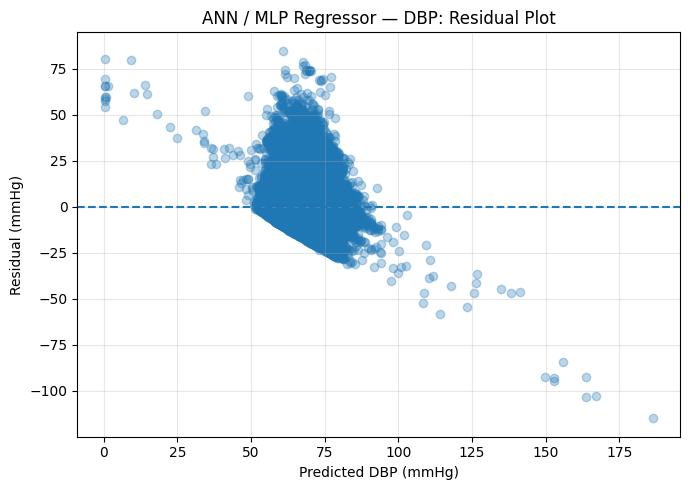

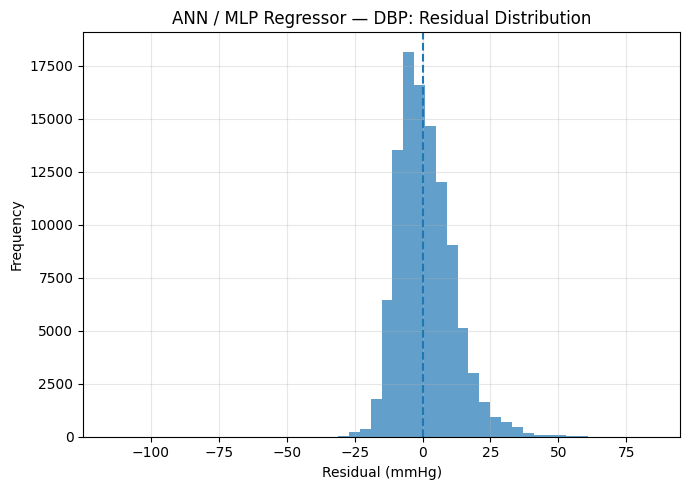

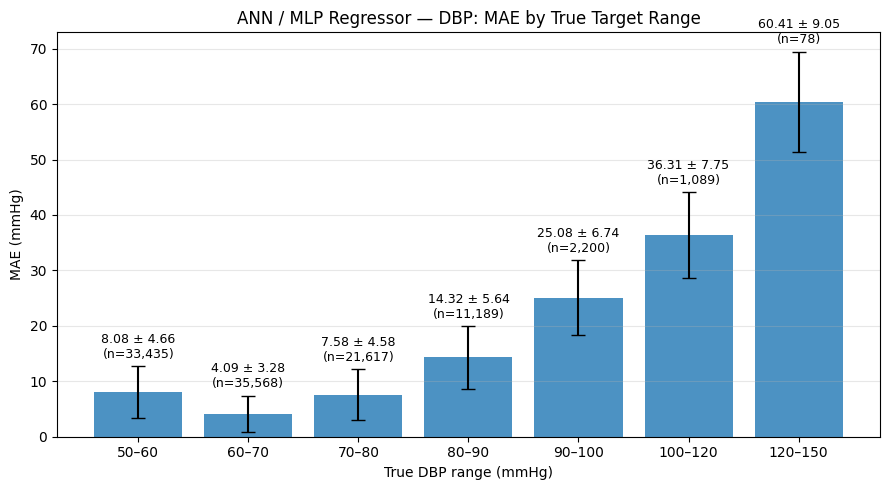

In [36]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

Processed 10,000 / 9,271,840
Processed 20,000 / 9,271,840
Processed 30,000 / 9,271,840
Processed 40,000 / 9,271,840
Processed 50,000 / 9,271,840
Processed 60,000 / 9,271,840
Processed 70,000 / 9,271,840
Processed 80,000 / 9,271,840
Processed 90,000 / 9,271,840
Processed 100,000 / 9,271,840
Processed 110,000 / 9,271,840
Processed 120,000 / 9,271,840
Processed 130,000 / 9,271,840
Processed 140,000 / 9,271,840
Processed 150,000 / 9,271,840
Processed 160,000 / 9,271,840
Processed 170,000 / 9,271,840
Processed 180,000 / 9,271,840
Processed 190,000 / 9,271,840
Processed 200,000 / 9,271,840
Processed 210,000 / 9,271,840
Processed 220,000 / 9,271,840
Processed 230,000 / 9,271,840
Processed 240,000 / 9,271,840
Processed 250,000 / 9,271,840
Processed 260,000 / 9,271,840
Processed 270,000 / 9,271,840
Processed 280,000 / 9,271,840
Processed 290,000 / 9,271,840
Processed 300,000 / 9,271,840
Processed 310,000 / 9,271,840
Processed 320,000 / 9,271,840
Processed 330,000 / 9,271,840
Processed 340,000 /

/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


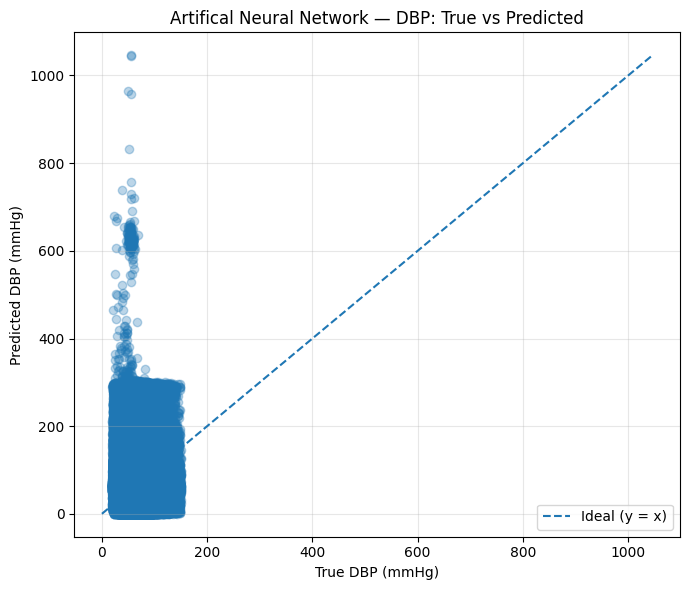

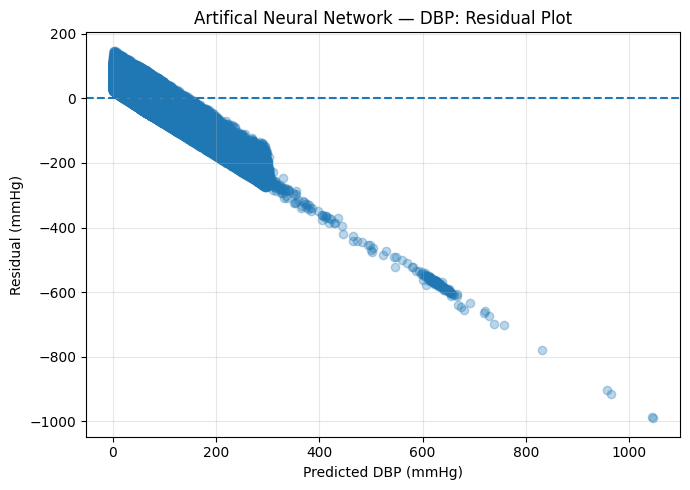

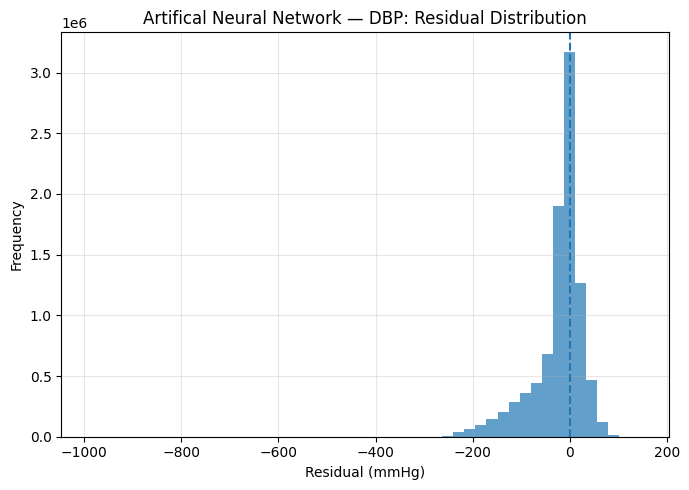

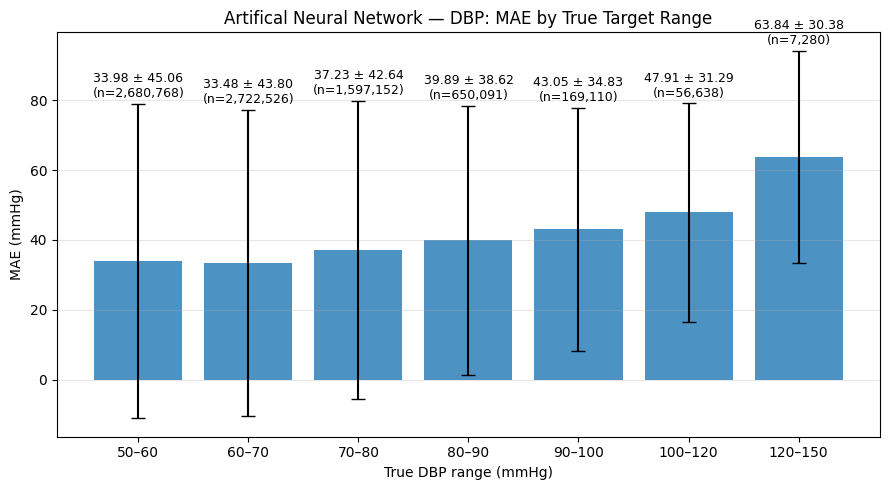

In [37]:
y_pred_vitaldb = predict_ann_in_batches(
    ann_model,
    X_test_vital,
y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)